# Data prep

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import ast
import matplotlib.pyplot as plt
import geopandas as gpd
%matplotlib inline

pd.set_option('future.no_silent_downcasting', True)

#### Loading the data

In [ ]:
try:
    la_df = pd.read_csv('/listings LA.csv')
    ny_df = pd.read_csv('/listings NYC.csv')
except:
    la_df = pd.read_csv('listings LA.csv')
    ny_df = pd.read_csv('listings NYC.csv')

la_cols = la_df.columns.values
ny_cols = ny_df.columns.values

print(f'Both datasets have the exact same columns: {all(la_cols==ny_cols)}')

Both datasets have the exact same columns: True


In [ ]:
print(f'LA rows: {la_df.shape[0]}, NYC rows: {ny_df.shape[0]}')
len(la_cols)

LA rows: 45886, NYC rows: 36111


39

**Add Areas**

We used an extranel data to fit between latitude and longitude to the area of each listing.



NYC

In [ ]:
try:
    ny = pd.read_csv("/listings NYC.csv")
except:
    ny = pd.read_csv("listings NYC.csv")

ny_gdf = gpd.GeoDataFrame(
    ny,
    geometry=gpd.points_from_xy(ny["longitude"], ny["latitude"]),
    crs="EPSG:4326"
)

try:
    ny_boroughs = gpd.read_file("geo_data/nynta2020.dbf")
except:
    ny_boroughs = gpd.read_file("geo_data/nynta2020.shp")

ny_boroughs = ny_boroughs.to_crs("EPSG:4326")

ny_joined = gpd.sjoin(
    ny_gdf,
    ny_boroughs[["BoroName", "geometry"]],
    how="left",
    predicate="within"
)

ny_joined["area"] = ny_joined["BoroName"]

ny_final = (
    ny_joined
    .drop(columns=["geometry", "index_right", "BoroName"], errors="ignore")
)


LA

In [ ]:
try:
    la = pd.read_csv("listings LA.csv")
except:
    la = pd.read_csv("/listings LA.csv")

la_gdf = gpd.GeoDataFrame(
    la,
    geometry=gpd.points_from_xy(la["longitude"], la["latitude"]),
    crs="EPSG:4326"
)

try:
    spa = gpd.read_file("geo_data/Service_Planning_Areas_2022.geojson")
except:
    spa = gpd.read_file("geo_data/Service_Planning_Areas_2022.geojson")

spa = spa.to_crs("EPSG:4326")

la_joined = gpd.sjoin(
    la_gdf,
    spa[["SPA_NAME", "geometry"]],
    how="left",
    predicate="within"
)
la_joined["area"] = la_joined["SPA_NAME"]
la_joined["area"] = la_joined["area"].fillna("Outside LA County")

la_final = (
    la_joined
    .drop(columns=["geometry", "index_right", "SPA_NAME"], errors="ignore")
)

In [ ]:
la_df = la_final
ny_df = ny_final

In [ ]:
la_df['area'].isna().value_counts()

,count
area,
False,45886


In [ ]:
ny_df['area'].isna().value_counts()

,count
area,
False,36109
True,2


Now lets find those two missing values by hand

In [ ]:
ny_df[ny_df['area'].isna()][['latitude','longitude']]

,latitude,longitude
14359,40.60392,-73.77046
25603,40.69340,-73.72636


After checking on google maps, both of them in Queens.

In [ ]:
ny_df.loc[[14359,25603], 'area']="Queens"

Since both dataframes share the same columns, we'll concatenate them into one dataframe, and add a column for 'city'. Then, we'll remove duplicate rows:

In [ ]:
la_df['city'] = 'LA'
ny_df['city'] = 'NY'
df = pd.concat([la_df, ny_df], ignore_index=True)
print(f'{df.duplicated().sum()} duplicate rows were removed.')
df = df.drop_duplicates()

50 duplicate rows were removed.


#### Converting columns to appropriate data types

In [ ]:
# assessing columns' data types
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 81947 entries, 0 to 81996
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   last_scraped               81947 non-null  object 
 1   name                       81944 non-null  object 
 2   description                80020 non-null  object 
 3   neighborhood_overview      38600 non-null  object 
 4   host_name                  80758 non-null  object 
 5   host_since                 80756 non-null  object 
 6   host_about                 44955 non-null  object 
 7   host_response_time         55868 non-null  object 
 8   host_response_rate         55868 non-null  object 
 9   host_acceptance_rate       56353 non-null  object 
 10  host_is_superhost          79801 non-null  object 
 11  host_listings_count        80756 non-null  float64
 12  host_total_listings_count  80756 non-null  float64
 13  host_verifications         80756 non-null  object 


,last_scraped,name,description,neighborhood_overview,host_name,host_since,host_about,host_response_time,host_response_rate,host_acceptance_rate,...,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,estimated_occupancy_l365d,first_review,last_review,instant_bookable,review_scores_rating,area,city
0,2025-09-02,"Blueground | W. Hollywood, nr shops & melrose",Show up and start living from day one in Los A...,This furnished apartment is located in Melrose...,Blueground,2016-12-16,"We’re Blueground, a global proptech company wi...",within an hour,100%,97%,...,1125.0,31.0,1125.0,0,NaN,NaN,t,NaN,Metro,LA
1,2025-09-02,"Bright Open Space Near Beach, Marina and LAX",Welcome to this light-filled private guest hou...,NaN,Veronique,2014-03-19,As a former flight attendant with nearly 15 ye...,within an hour,100%,100%,...,365.0,2.0,365.0,126,2024-05-12,2025-08-24,f,5.0,West,LA
2,2025-09-03,Dreamy Nights Near Hollywood & Highland Center,"We are located on the Hollywood Walk of Fame, ...",- Hollywood Walk of Fame - 0 miles (Right outs...,RoomPicks,2023-02-20,NaN,within an hour,100%,90%,...,1125.0,1.0,852.9,0,NaN,NaN,t,NaN,Metro,LA
3,2025-09-02,Lovely home near the beach & pier,Forget your worries in this spacious and seren...,NaN,Sean,2014-06-07,NaN,within an hour,100%,100%,...,365.0,30.0,365.0,120,2025-06-26,2025-07-28,f,5.0,South Bay,LA
4,2025-09-02,Sunlit Two Bedroom + Office in Beachwood Canyon,An incredible retreat in the hills. Two bedroo...,NaN,Jena,2011-10-11,"After 15 years in NYC, I now live in Los Angel...",within a few hours,100%,60%,...,60.0,4.0,60.0,8,2023-03-18,2025-06-26,f,5.0,Metro,LA


The following columns should be converted so that they contain the corresponding data types:
* last_scraped, host_since, first_review, last_review -> pd.datetime
* host_response_rate, host_acceptance_rate, price -> numeric
* host_is_superhost, host_has_profile_pic, instant_bookable -> bool
* host_verifications, amenities -> list

In [ ]:
# datetime columns
date_cols = ['last_scraped', 'host_since', 'first_review', 'last_review']
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')

# numeric columns
numeric_cols = ['host_response_rate', 'host_acceptance_rate', 'price']
df[numeric_cols] = (df[numeric_cols].replace(r'\s*[$%,]\s*', '', regex=True).apply(pd.to_numeric, errors='coerce'))

# boolean columns
bool_cols = ['host_is_superhost', 'host_has_profile_pic', 'instant_bookable']
df[bool_cols] = df[bool_cols].replace({'t': True, 'f': False})

# list columns
df['host_verifications'] = df['host_verifications'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df['amenities'] = df['amenities'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Quick raw data visualization

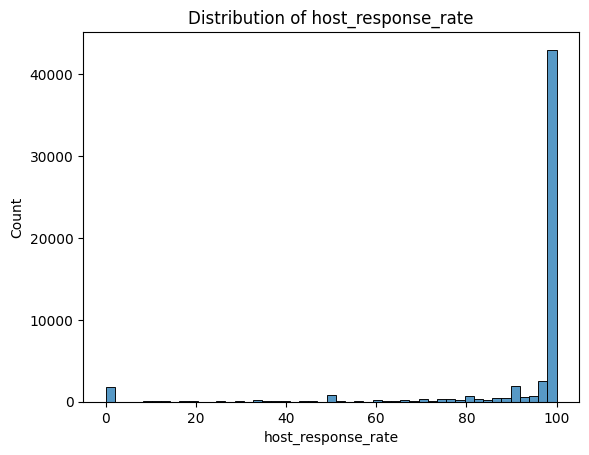

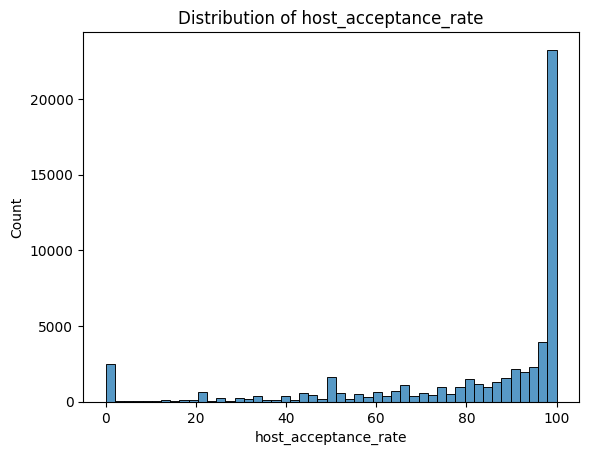

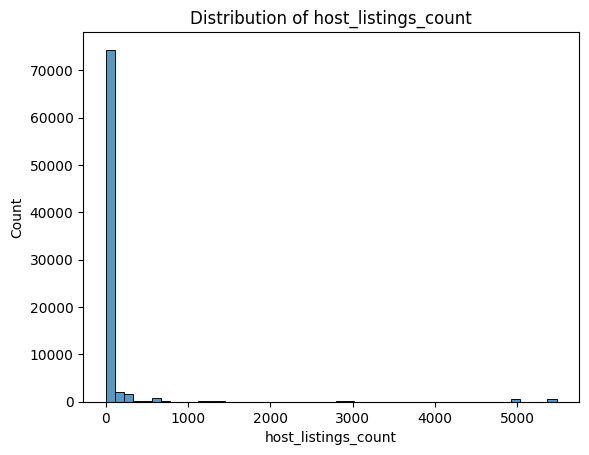

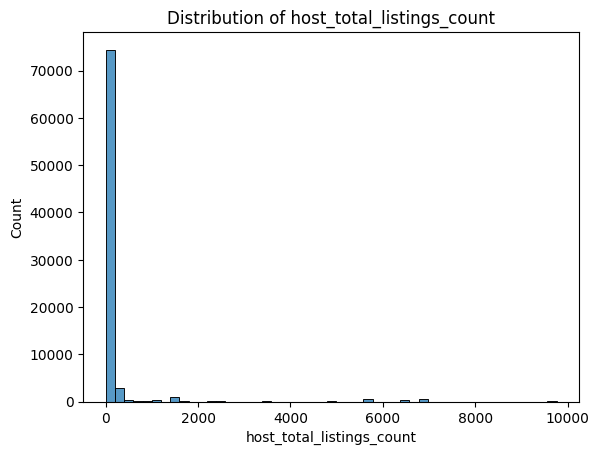

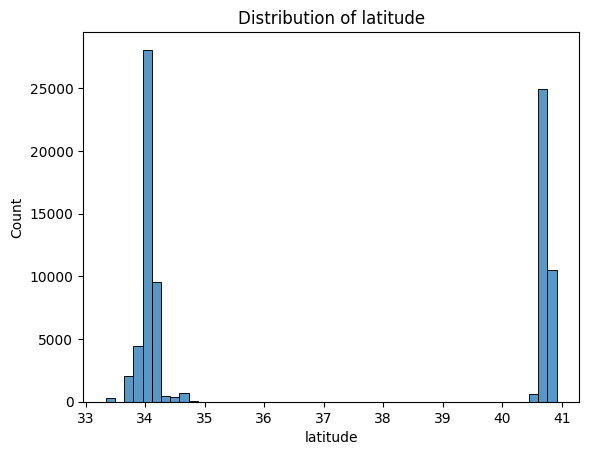

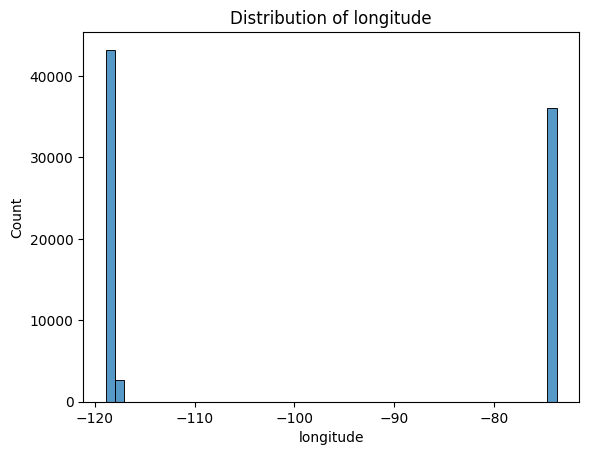

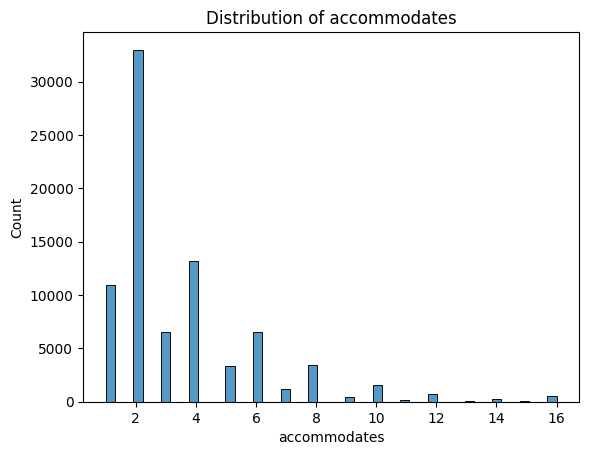

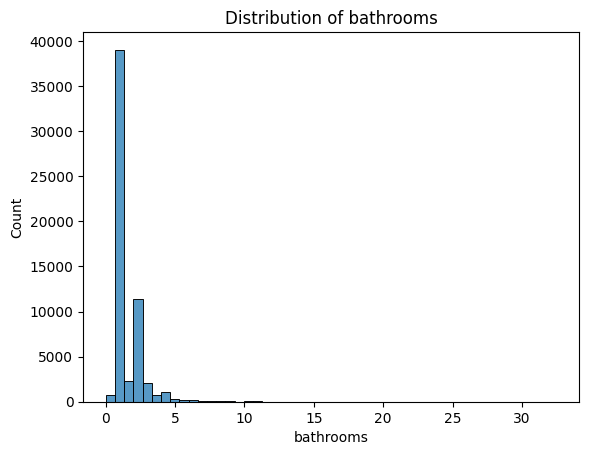

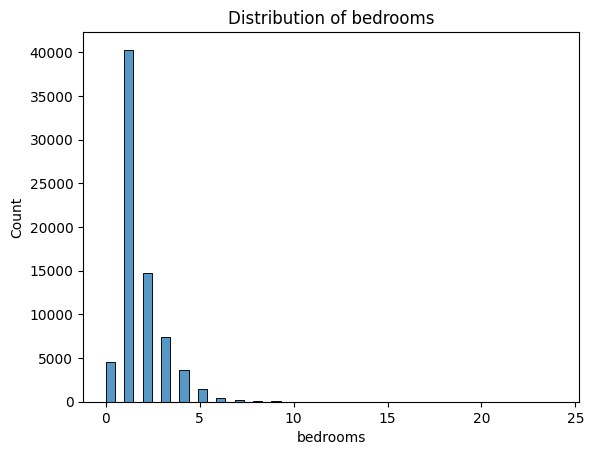

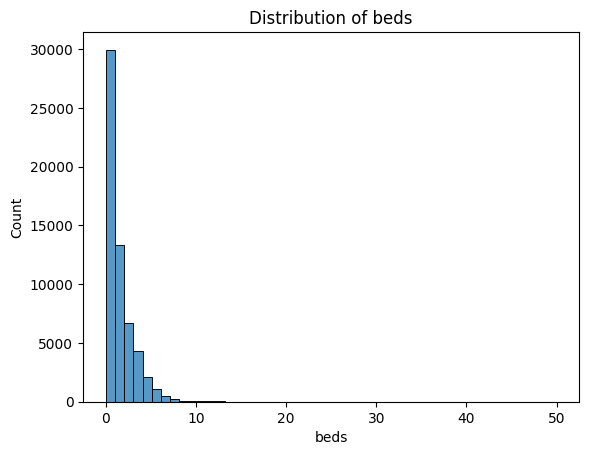

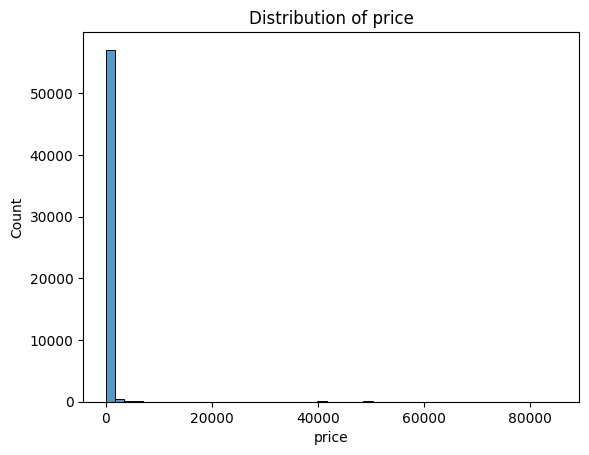

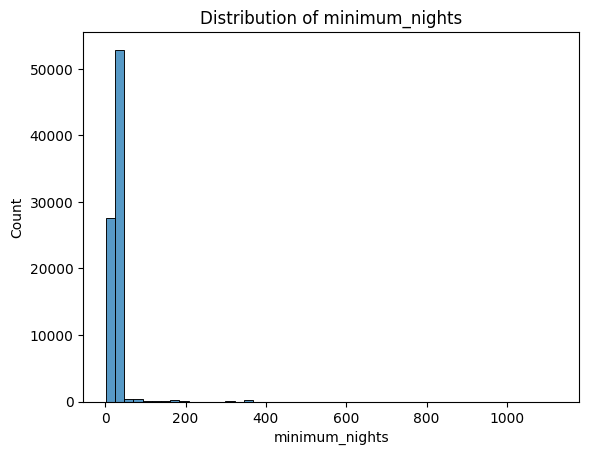

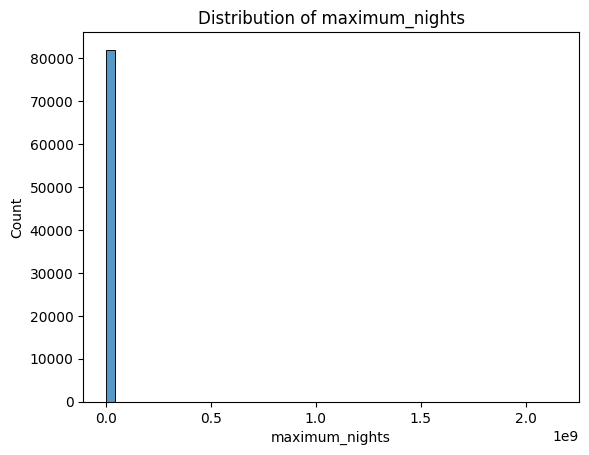

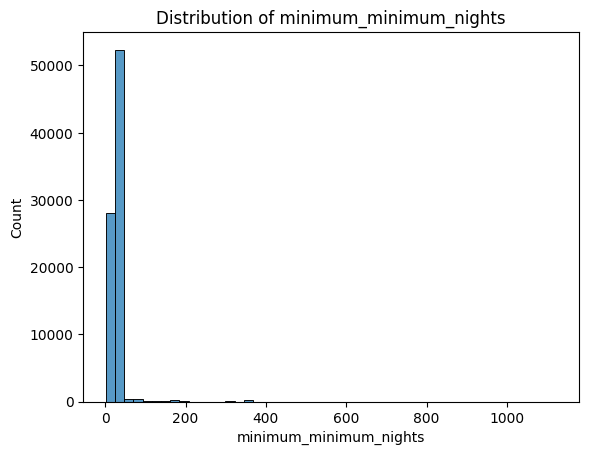

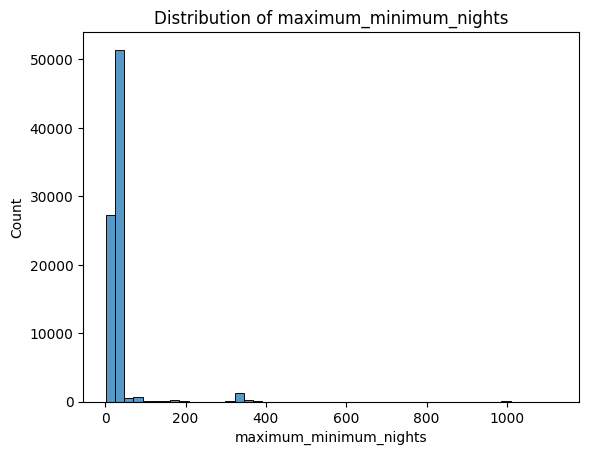

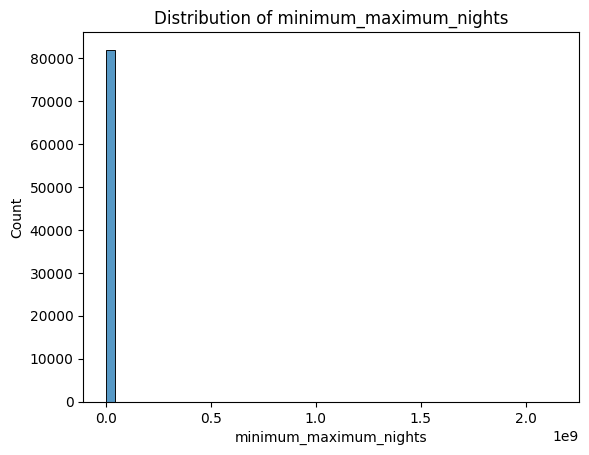

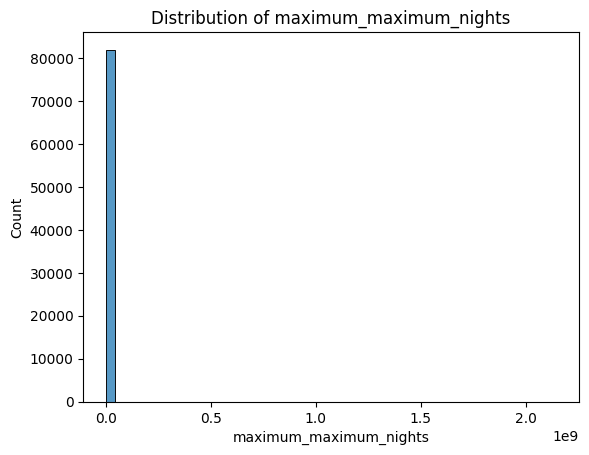

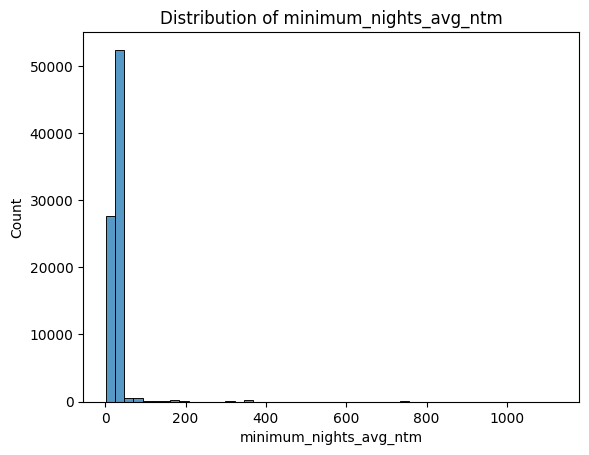

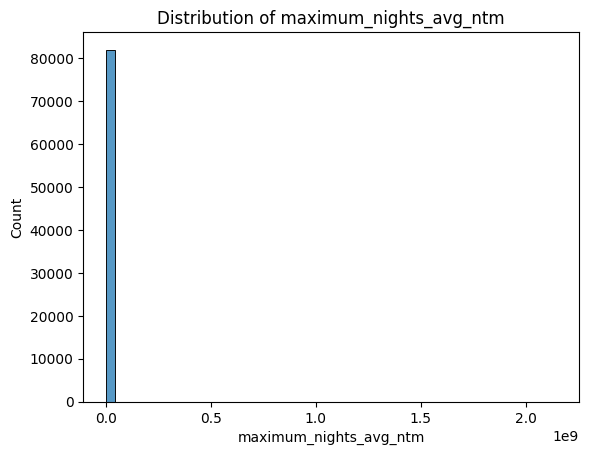

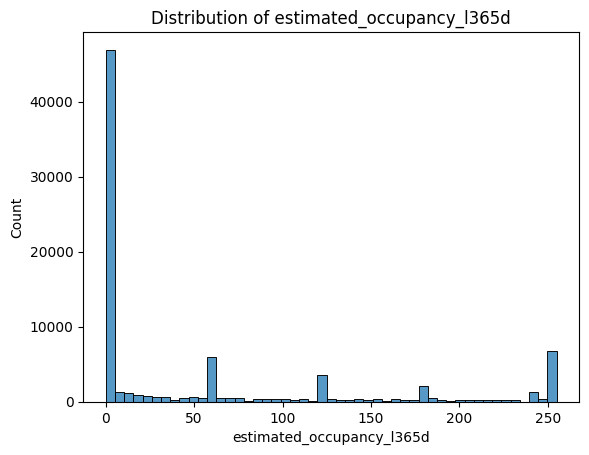

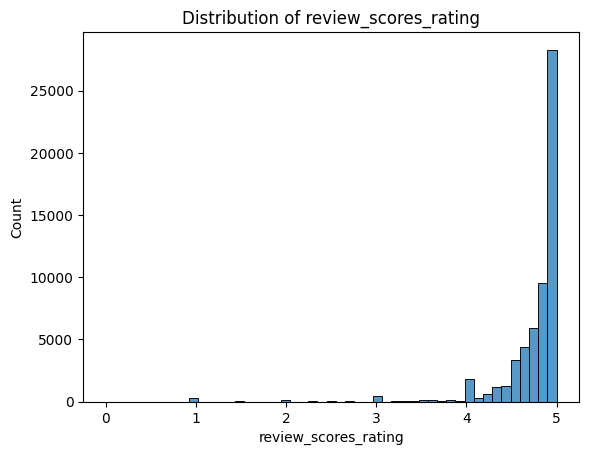

In [ ]:
numeric_columns = df.columns[df.dtypes.apply(lambda x: np.issubdtype(x, np.number))]
for col in numeric_columns:
    plt.figure()
    data = df[col].dropna()
    bins = np.linspace(data.min(), data.max(), 50)
    sns.histplot(data, bins=bins)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()


#### Handling missing data

In order to decide how to handle missing values in each column, we should first consider how many missing values there are in each column.

In [ ]:
def summarize_missing_values(df):
  missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
  }).sort_values('Missing_Percentage', ascending=False)

  print("Missing Values Summary:")
  print(missing_summary[missing_summary['Missing_Percentage'] > 0])

summarize_missing_values(df)


Missing Values Summary:
                           Missing_Count  Missing_Percentage
neighborhood_overview              43347               52.90
host_about                         36992               45.14
host_response_time                 26079               31.82
host_response_rate                 26079               31.82
host_acceptance_rate               25594               31.23
price                              23846               29.10
review_scores_rating               23639               28.85
first_review                       23639               28.85
last_review                        23639               28.85
beds                               23495               28.67
bathrooms                          23390               28.54
bedrooms                            8987               10.97
host_is_superhost                   2146                2.62
description                         1927                2.35
host_verifications                  1191                1.45


First, rows without values of the dependent variable should be removed.

In [ ]:
cleaned_df = df.loc[df['review_scores_rating'].notna()]
summarize_missing_values(cleaned_df)

Missing Values Summary:
                           Missing_Count  Missing_Percentage
neighborhood_overview              26536               45.51
host_about                         24519               42.05
host_response_time                 16015               27.47
host_response_rate                 16015               27.47
price                              15984               27.41
beds                               15744               27.00
bathrooms                          15678               26.89
host_acceptance_rate               14942               25.63
bedrooms                            6092               10.45
host_is_superhost                   1661                2.85
description                          885                1.52
host_name                            192                0.33
host_since                           194                0.33
host_has_profile_pic                 194                0.33
host_total_listings_count            194                0.33


It seems likely that missing host_name, host_since, host_verifications, host_has_profile_pic, host_total_listings_count and host_listings_count overlap. Let's check how many entries miss values in all of these columns:

In [ ]:
print(f'{(cleaned_df['host_name'].isna() & cleaned_df['host_since'].isna() & cleaned_df['host_verifications'].isna() & cleaned_df['host_has_profile_pic'].isna() & cleaned_df['host_total_listings_count'].isna() & cleaned_df['host_listings_count'].isna()).sum()} miss values in all listed columns.')
print(f'{(cleaned_df['host_name'].isna() | cleaned_df['host_since'].isna() | cleaned_df['host_verifications'].isna() | cleaned_df['host_has_profile_pic'].isna() | cleaned_df['host_total_listings_count'].isna() | cleaned_df['host_listings_count'].isna()).sum()} miss values in at least one of the listed columns.')

192 miss values in all listed columns.
194 miss values in at least one of the listed columns.


Since the overlap is (almost) perfect, we'll remove all of these entries.

In [ ]:
cleaned_df = cleaned_df.loc[~(cleaned_df['host_name'].isna() | cleaned_df['host_since'].isna() | cleaned_df['host_verifications'].isna() | cleaned_df['host_has_profile_pic'].isna() | cleaned_df['host_total_listings_count'].isna() | cleaned_df['host_listings_count'].isna())]
summarize_missing_values(cleaned_df)

Missing Values Summary:
                        Missing_Count  Missing_Percentage
neighborhood_overview           26464               45.54
host_about                      24325               41.86
price                           15959               27.46
host_response_rate              15821               27.22
host_response_time              15821               27.22
beds                            15719               27.05
bathrooms                       15653               26.93
host_acceptance_rate            14748               25.38
bedrooms                         6086               10.47
host_is_superhost                1659                2.85
description                       883                1.52
bathrooms_text                     69                0.12
minimum_minimum_nights             21                0.04
maximum_minimum_nights             21                0.04
minimum_maximum_nights             21                0.04
maximum_maximum_nights             21           

As all remaining entries have minimum_nights and maximum_nights, we can assign these values to the corresponding minimum/maximum_minimum/maximum_nights columns:

In [ ]:
cleaned_df['minimum_minimum_nights'] = cleaned_df['minimum_minimum_nights'].fillna(cleaned_df['minimum_nights'])
cleaned_df['maximum_minimum_nights'] = cleaned_df['maximum_minimum_nights'].fillna(cleaned_df['minimum_nights'])
cleaned_df['minimum_maximum_nights'] = cleaned_df['minimum_maximum_nights'].fillna(cleaned_df['maximum_nights'])
cleaned_df['maximum_maximum_nights'] = cleaned_df['maximum_maximum_nights'].fillna(cleaned_df['maximum_nights'])
summarize_missing_values(cleaned_df)

Missing Values Summary:
                       Missing_Count  Missing_Percentage
neighborhood_overview          26464               45.54
host_about                     24325               41.86
price                          15959               27.46
host_response_rate             15821               27.22
host_response_time             15821               27.22
beds                           15719               27.05
bathrooms                      15653               26.93
host_acceptance_rate           14748               25.38
bedrooms                        6086               10.47
host_is_superhost               1659                2.85
description                      883                1.52
bathrooms_text                    69                0.12


Almost all rows have values in bathrooms_text. To recover missing bathrooms data, We'll group by the corresponding text column and assign the group's mode to the missing rows. Only a few rows miss data in bathroom_text, so we'll remove these rows if they also miss numeric bathroom data.

In [ ]:
# Bathrooms
missing_rows = cleaned_df['bathrooms'].isna().sum()
print(f'Trying to recover bathrooms data in {(cleaned_df['bathrooms'].isna() & cleaned_df['bathrooms_text'].notna()).sum()} rows out of {cleaned_df['bathrooms'].isna().sum()}.')
cleaned_df['bathrooms'] = cleaned_df.groupby('bathrooms_text')['bathrooms'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))
print(f'Successfully recovered bathrooms data in {missing_rows - cleaned_df['bathrooms'].isna().sum()} rows.')
print(f'Removing remaining {cleaned_df['bathrooms'].isna().sum()} rows.')
cleaned_df = cleaned_df.loc[cleaned_df['bathrooms'].notna()]
print()
summarize_missing_values(cleaned_df)

Trying to recover bathrooms data in 15617 rows out of 15653.
Successfully recovered bathrooms data in 15583 rows.
Removing remaining 70 rows.

Missing Values Summary:
                       Missing_Count  Missing_Percentage
neighborhood_overview          26443               45.56
host_about                     24271               41.81
price                          15929               27.44
host_response_rate             15812               27.24
host_response_time             15812               27.24
beds                           15690               27.03
host_acceptance_rate           14741               25.40
bedrooms                        6083               10.48
host_is_superhost               1659                2.86
description                      878                1.51


Intuitively, number of beds should correlate with how many people a property accommodates. Let's verify that:

In [ ]:
from scipy.stats import pearsonr

rows_to_corr = cleaned_df['beds'].notna()
r, p = pearsonr(cleaned_df.loc[rows_to_corr, 'beds'], cleaned_df.loc[rows_to_corr, 'accommodates'])
print(f"Pearson Correlation between beds and accomodates: {r:.4f}, p-value: {p:.4f}")

Pearson Correlation between beds and accomodates: 0.8208, p-value: 0.0000


There's a strong, significant correlation between the two, so we'll group the data by accommodates values and fill the missing beds values with their group's median.

In [ ]:
cleaned_df['beds'] = cleaned_df.groupby('accommodates')['beds'].transform(lambda x: x.fillna(x.median()))
summarize_missing_values(cleaned_df)

Missing Values Summary:
                       Missing_Count  Missing_Percentage
neighborhood_overview          26443               45.56
host_about                     24271               41.81
price                          15929               27.44
host_response_rate             15812               27.24
host_response_time             15812               27.24
host_acceptance_rate           14741               25.40
bedrooms                        6083               10.48
host_is_superhost               1659                2.86
description                      878                1.51


We'll now repeat the same process with the 'bedrooms' column:

In [ ]:
rows_to_corr = cleaned_df['bedrooms'].notna()
r, p = pearsonr(cleaned_df.loc[rows_to_corr, 'bedrooms'], cleaned_df.loc[rows_to_corr, 'accommodates'])
print(f"Pearson Correlation between beds and accommodates: {r:.4f}, p-value: {p:.4f}")

Pearson Correlation between beds and accommodates: 0.7927, p-value: 0.0000


In [ ]:
cleaned_df['bedrooms'] = cleaned_df.groupby('accommodates')['bedrooms'].transform(lambda x: x.fillna(x.median()))
summarize_missing_values(cleaned_df)

Missing Values Summary:
                       Missing_Count  Missing_Percentage
neighborhood_overview          26443               45.56
host_about                     24271               41.81
price                          15929               27.44
host_response_rate             15812               27.24
host_response_time             15812               27.24
host_acceptance_rate           14741               25.40
host_is_superhost               1659                2.86
description                      878                1.51


If a host misses a 'host_is_superhost' value, it means they are not a superhost (otherwise they would have had this badge). Imputed entries are flagged in an additional 'host_is_superhos_imputed' column.

In [ ]:
cleaned_df['host_is_superhost_imputed'] = cleaned_df['host_is_superhost'].isna()
cleaned_df['host_is_superhost'] = cleaned_df['host_is_superhost'].fillna(False)

host_response_time is a categorical variable. We'll add a new column where each category is coded as a dummy number, and missing data is coded as 0.

In [ ]:
mapping_dict = {'within an hour': 1, 'within a few hours': 2, 'within a day': 3, 'a few days or more': 4}
cleaned_df['host_response_time_coded'] = cleaned_df['host_response_time'].map(mapping_dict).fillna(0)
summarize_missing_values(cleaned_df)

Missing Values Summary:
                       Missing_Count  Missing_Percentage
neighborhood_overview          26443               45.56
host_about                     24271               41.81
price                          15929               27.44
host_response_time             15812               27.24
host_response_rate             15812               27.24
host_acceptance_rate           14741               25.40
description                      878                1.51


host_response_rate and host_acceptance_rate are both numeric. Let's examine their distributions:

       host_acceptance_rate  host_response_rate
count          43303.000000        42232.000000
mean              84.682678           94.059812
std               24.146991           18.380674
min                0.000000            0.000000
25%               80.000000           99.000000
50%               96.000000          100.000000
75%              100.000000          100.000000
max              100.000000          100.000000


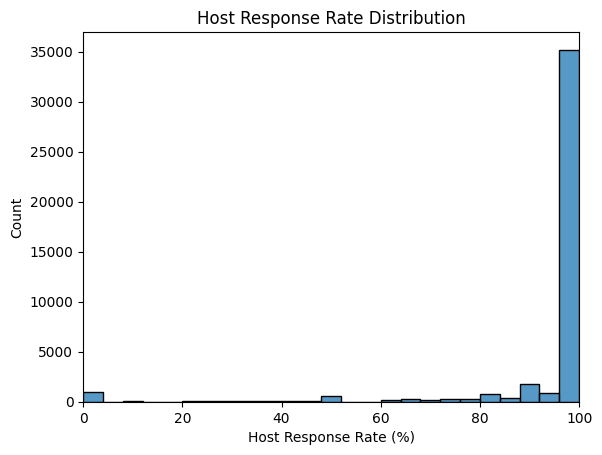

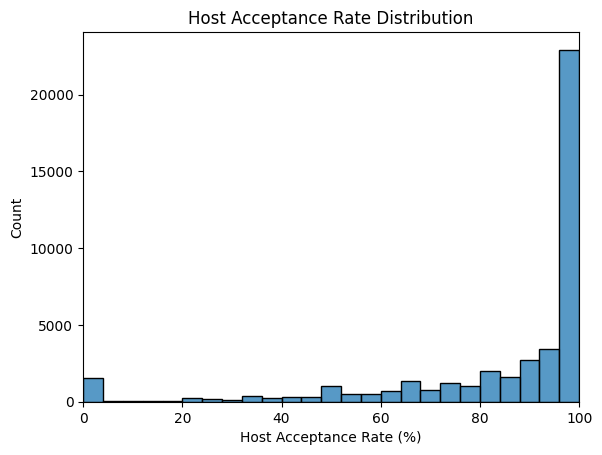

In [ ]:
print(cleaned_df[['host_acceptance_rate', 'host_response_rate']].describe())

bins = np.linspace(0, 100, 26)
sns.histplot(cleaned_df['host_response_rate'].dropna(), bins=bins)
plt.title('Host Response Rate Distribution')
plt.xlabel('Host Response Rate (%)')
plt.xlim(0, 100)
plt.show()

sns.histplot(cleaned_df['host_acceptance_rate'].dropna(), bins=bins)
plt.title('Host Acceptance Rate Distribution')
plt.xlabel('Host Acceptance Rate (%)')
plt.xlim(0, 100)
plt.show()

There are hosts with acceptance/response rates of 0,
which is suspicious given they have rating scores.
Maybe it's related to last_review so that inactive hosts' rates are 0?

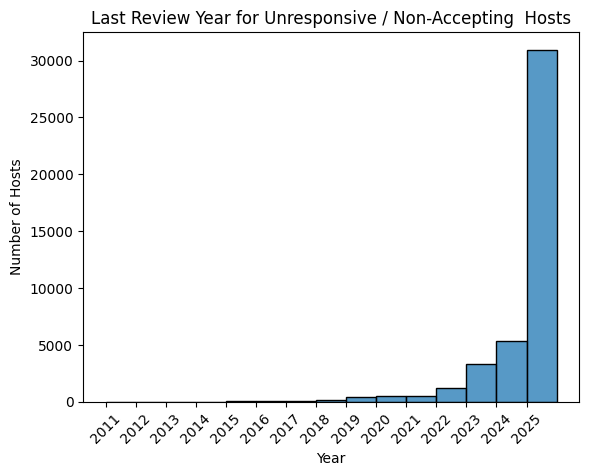

In [ ]:
unresponsive_hosts = (cleaned_df['host_acceptance_rate']==0) | (cleaned_df['host_response_rate'].isna()==0)
unresponsive_hosts_last_review = cleaned_df['last_review'].dt.year.loc[unresponsive_hosts]
min_year = unresponsive_hosts_last_review.min()
max_year = unresponsive_hosts_last_review.max()
bins = range(min_year, max_year + 2)
sns.histplot(unresponsive_hosts_last_review, bins=bins, edgecolor='black')
plt.title('Last Review Year for Unresponsive / Non-Accepting  Hosts')
plt.xlabel('Year')
plt.ylabel('Number of Hosts')
plt.xticks(range(min_year, max_year + 1), rotation=45)
plt.show()

Apparently it's not the case that hosts who weren't reviewed lately have low response and acceptance rates. Rather, out of the non-responsive/accepting hosts, the most were reviewed in the last year.

As for the missing data, each will be assigned the median rate (as the distributions are skewed) and flagged as imputed in a new column, 'host_*_rate_imputed'.


In [ ]:
for col in ['host_response_rate', 'host_acceptance_rate']:
    median_value = cleaned_df[col].median()
    cleaned_df[f'{col}_imputed'] = cleaned_df[col].isna()
    cleaned_df[col] = cleaned_df[col].fillna(median_value)

summarize_missing_values(cleaned_df)

Missing Values Summary:
                       Missing_Count  Missing_Percentage
neighborhood_overview          26443               45.56
host_about                     24271               41.81
price                          15929               27.44
host_response_time             15812               27.24
description                      878                1.51


Since there are a lot of rows without neighborhood_overview and host_about, we create 2 new binary features that will be used in the analysis instead: has_neighborhood_overview and has_host_about.

In [ ]:
cleaned_df['has_neighborhood_overview'] = cleaned_df['neighborhood_overview'].notna()
cleaned_df['has_host_about'] = cleaned_df['host_about'].notna()

### Prices

Before deciding how to impute missing price values, let's examine the prices distribution:

<Axes: xlabel='price', ylabel='Count'>

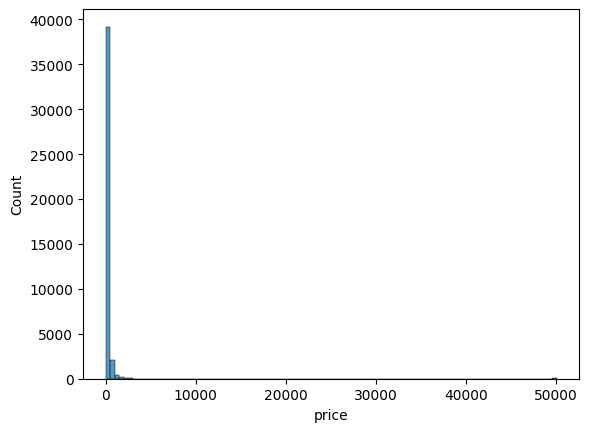

In [ ]:
# Distribution of prices
bins = np.linspace(0, cleaned_df['price'].max(), 100)
sns.histplot(cleaned_df['price'].dropna(), bins=bins)

There are a few extreme outliers that greatly affect the mean price. However, we cannot reject them, as it's possible for rental prices of luxury properties to be high. To mitigate their effect, we'll use the log-transformed prices:

Text(0.5, 0, 'log-transformed price')

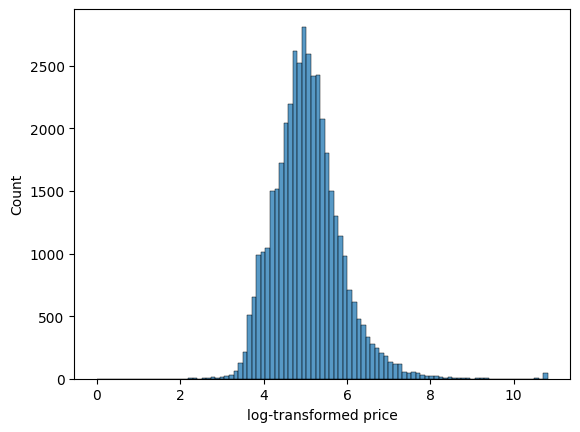

In [ ]:
# Distribution of log-transformed prices
bins = np.linspace(0, np.log(cleaned_df['price']).max(), 100)
sns.histplot(np.log(cleaned_df['price'].dropna()), bins=bins)
plt.xlabel('log-transformed price')

Entries without prices will be flagged and assigned the mean log-transformed price of other similar properties that accommodate the same number of people in their area.

In [ ]:
cleaned_df['log_price'] = np.log(cleaned_df['price'])
cleaned_df['log_price_imputed'] = cleaned_df['price'].isna()
cleaned_df['log_price'] = cleaned_df.groupby(['accommodates', 'area'])['log_price'].transform(lambda x: x.fillna(x.mean()))

Let's investigate host_listings_count and host_total_listings_count's distributions:

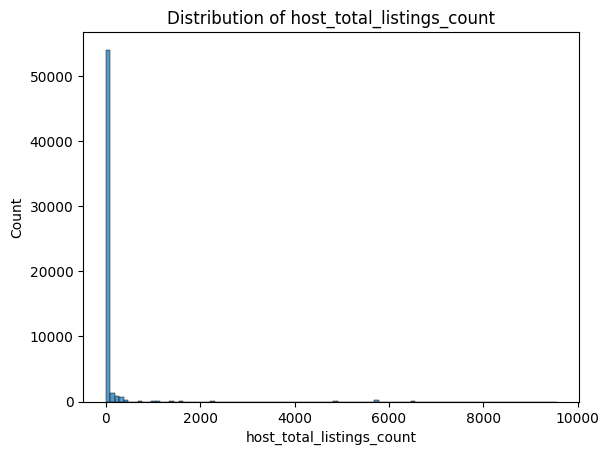

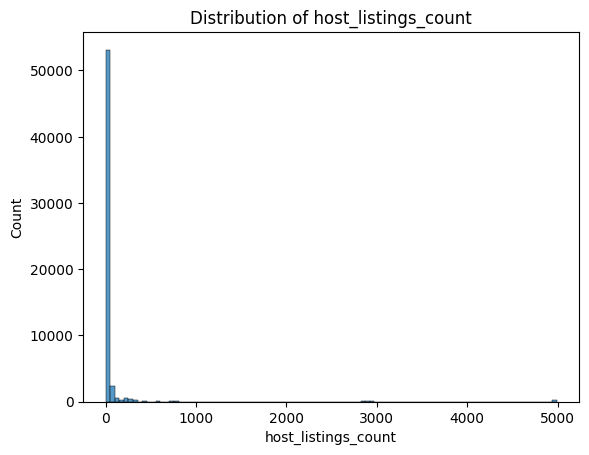

In [ ]:
bins = np.linspace(0, (cleaned_df['host_total_listings_count']).max(), 100)
sns.histplot(cleaned_df['host_total_listings_count'], bins=bins)
plt.xlabel('host_total_listings_count')
plt.title('Distribution of host_total_listings_count')
plt.show()

bins = np.linspace(0, (cleaned_df['host_listings_count']).max(), 100)
sns.histplot(cleaned_df['host_listings_count'], bins=bins)
plt.xlabel('host_listings_count')
plt.title('Distribution of host_listings_count')
plt.show()


Both have extreme outliers, so we'll log-transform these columns as well.

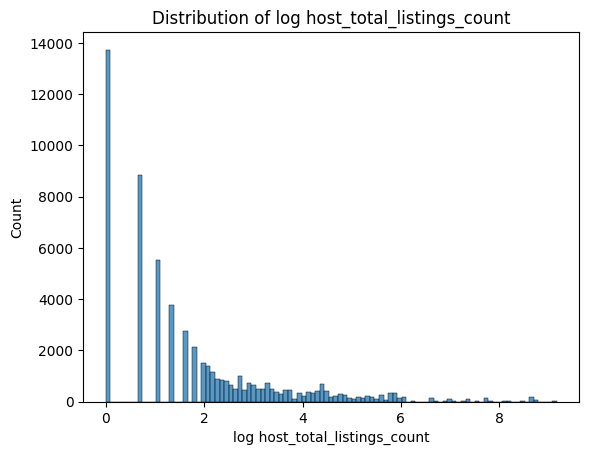

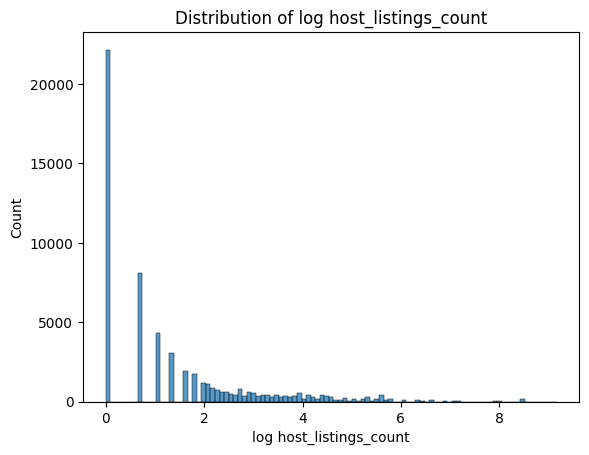

In [ ]:
cleaned_df['log_host_total_listings_count'] = np.log(cleaned_df['host_total_listings_count'])
cleaned_df['log_host_listings_count'] = np.log(cleaned_df['host_listings_count'])


bins = np.linspace(0, (cleaned_df['log_host_total_listings_count']).max(), 100)
sns.histplot(cleaned_df['log_host_total_listings_count'], bins=bins)
plt.xlabel('log host_total_listings_count')
plt.title('Distribution of log host_total_listings_count')
plt.show()

bins = np.linspace(0, (cleaned_df['log_host_total_listings_count']).max(), 100)
sns.histplot(cleaned_df['log_host_listings_count'], bins=bins)
plt.xlabel('log host_listings_count')
plt.title('Distribution of log host_listings_count')
plt.show()


Most entries have description. We should check later if the description length in characters or words is correlated with reviews scores.

In [ ]:
cleaned_df['description_length_words'] = cleaned_df['description'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
cleaned_df['description_length_chars'] = cleaned_df['description'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

#### interim summary

In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58044 entries, 1 to 81996
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   last_scraped                   58044 non-null  datetime64[ns]
 1   name                           58043 non-null  object        
 2   description                    57166 non-null  object        
 3   neighborhood_overview          31601 non-null  object        
 4   host_name                      58044 non-null  object        
 5   host_since                     58044 non-null  datetime64[ns]
 6   host_about                     33773 non-null  object        
 7   host_response_time             42232 non-null  object        
 8   host_response_rate             58044 non-null  float64       
 9   host_acceptance_rate           58044 non-null  float64       
 10  host_is_superhost              58044 non-null  object        
 11  host_listings_count 

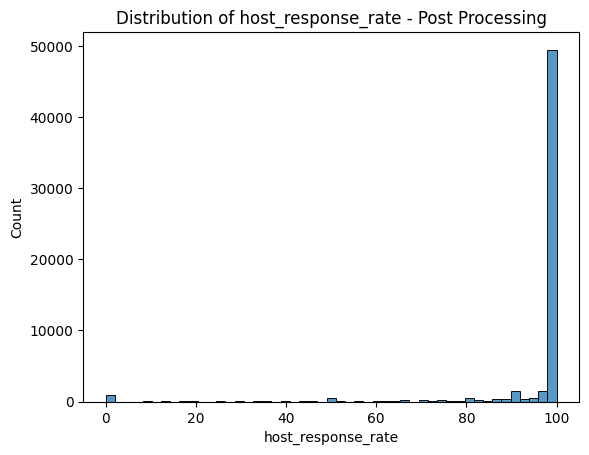

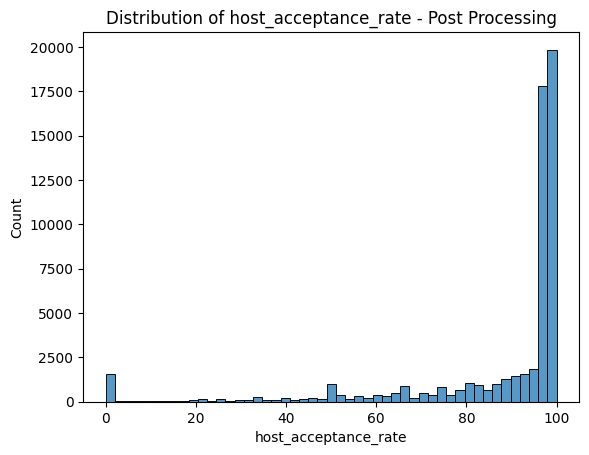

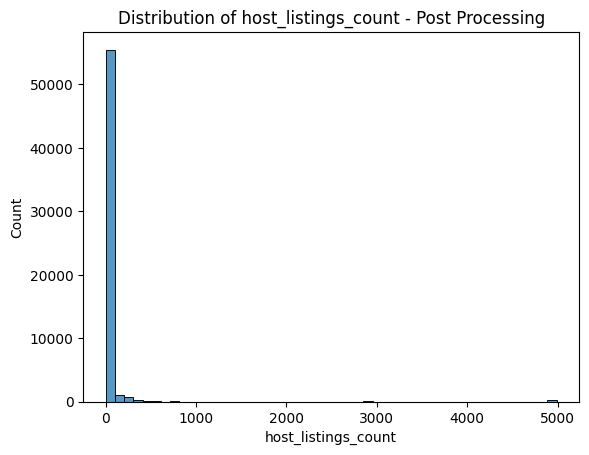

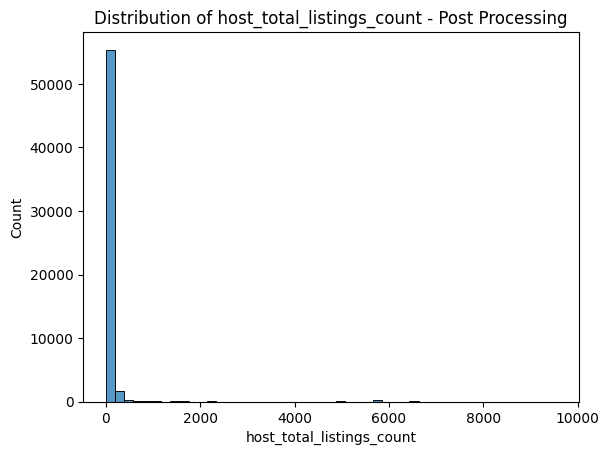

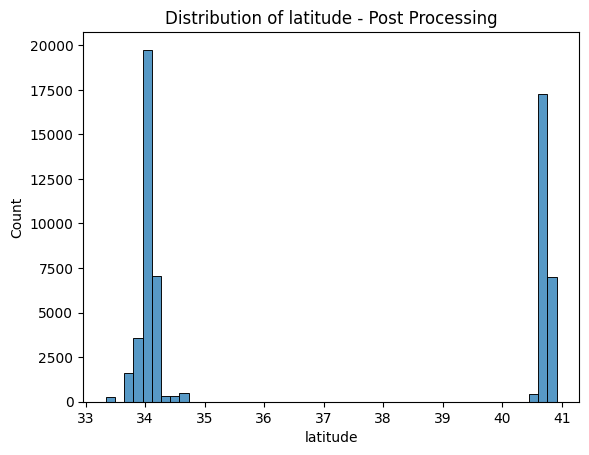

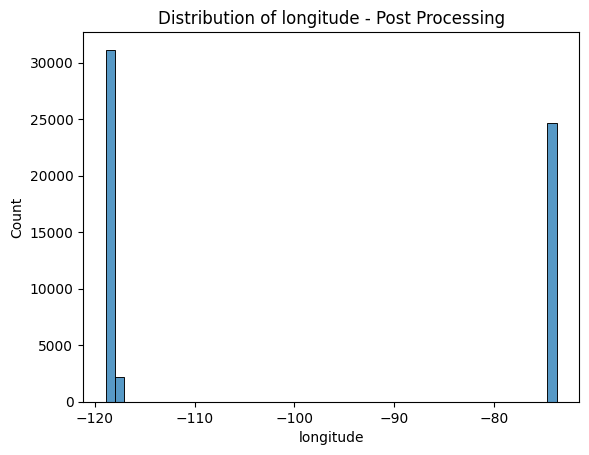

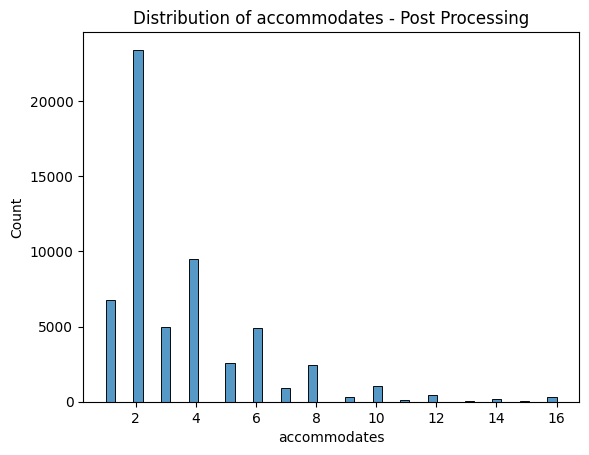

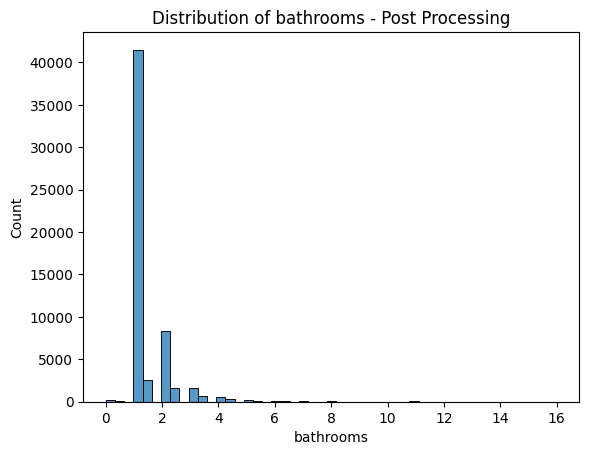

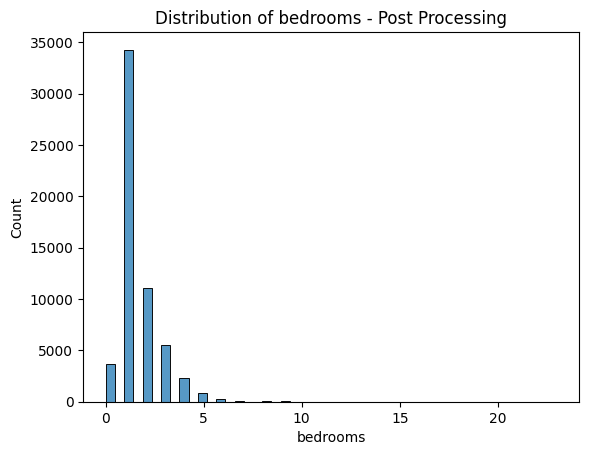

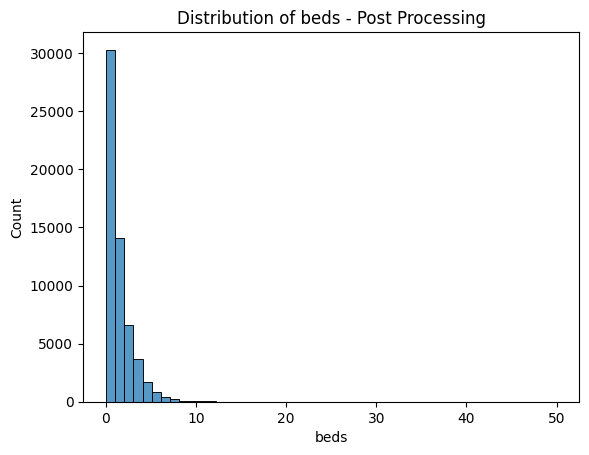

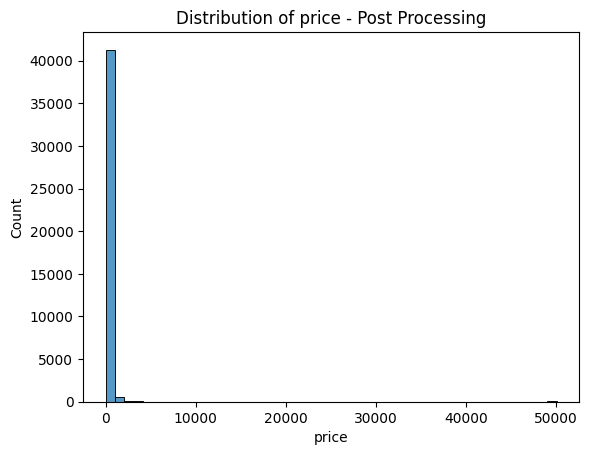

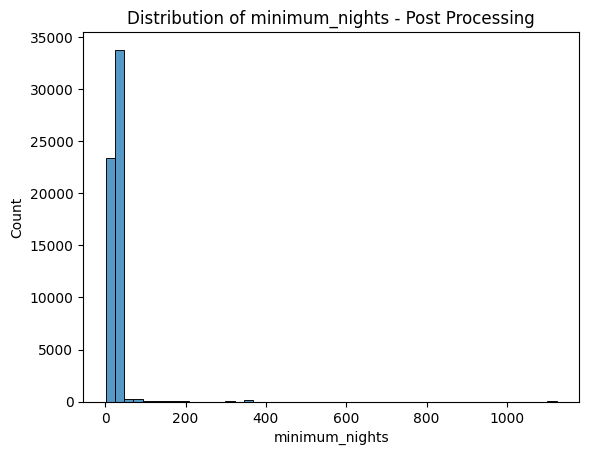

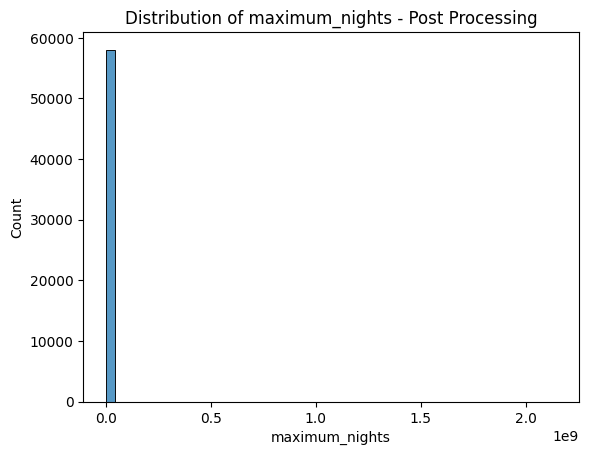

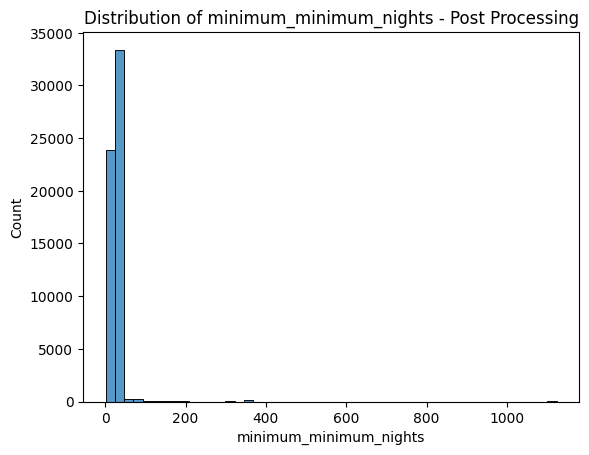

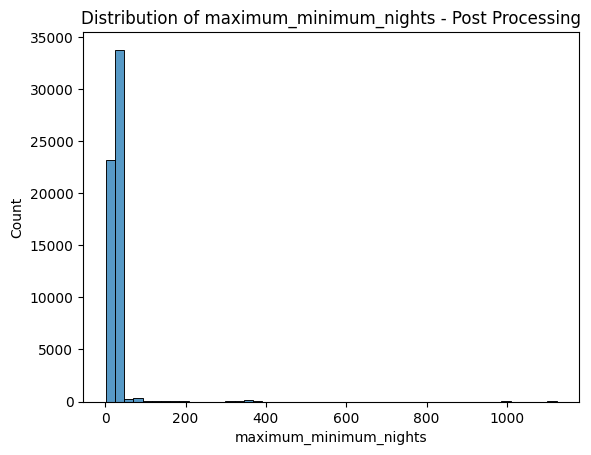

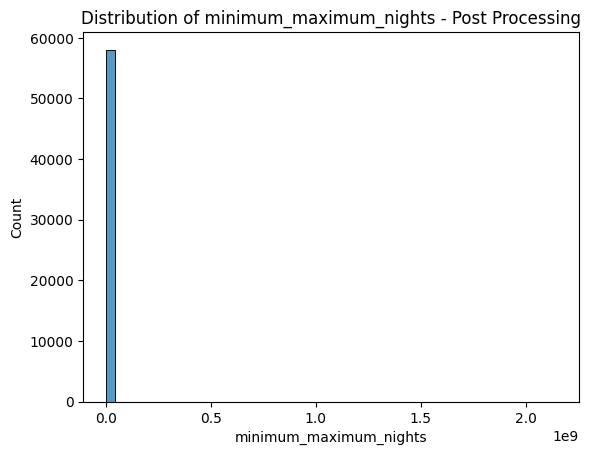

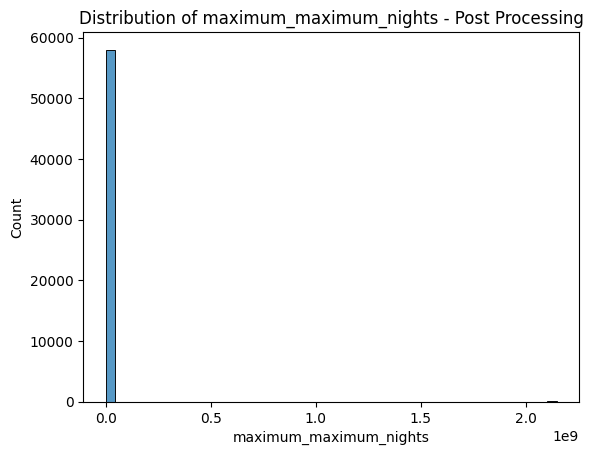

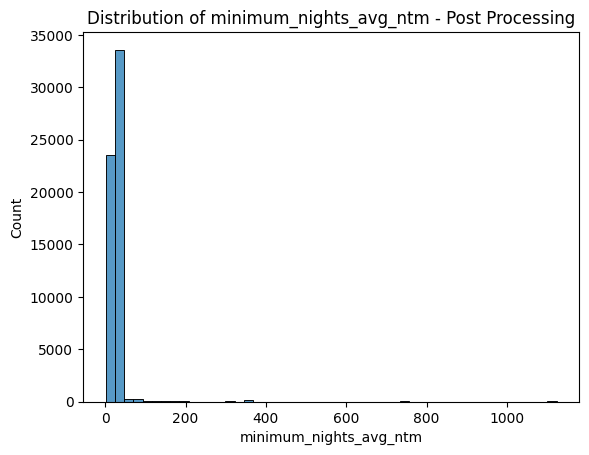

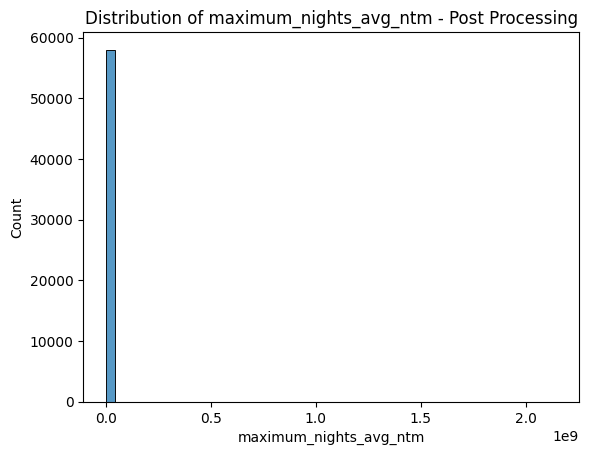

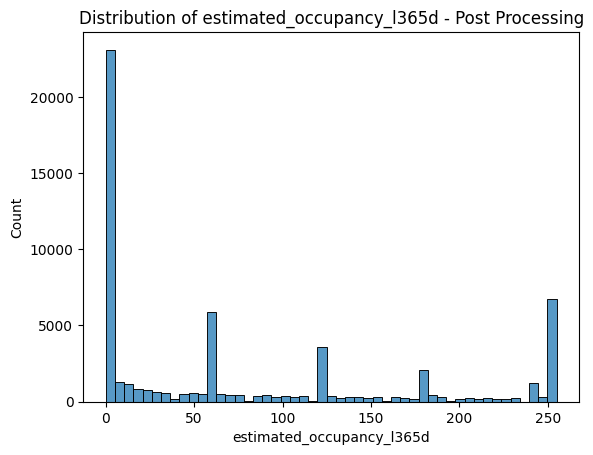

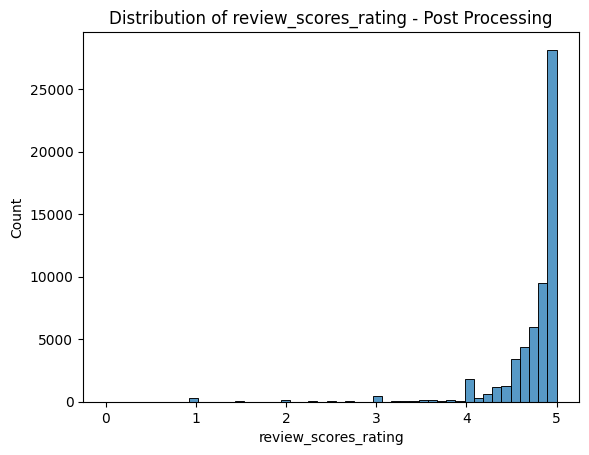

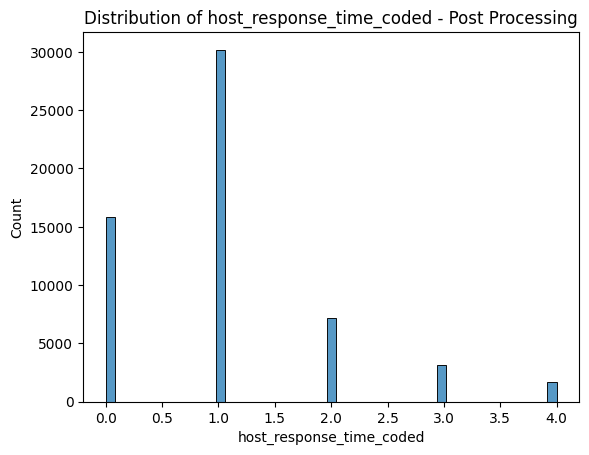

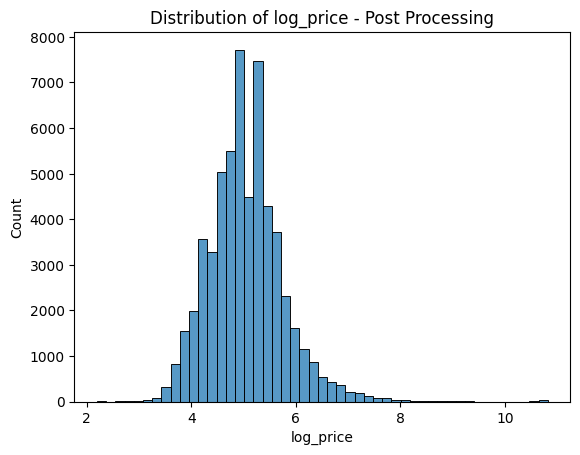

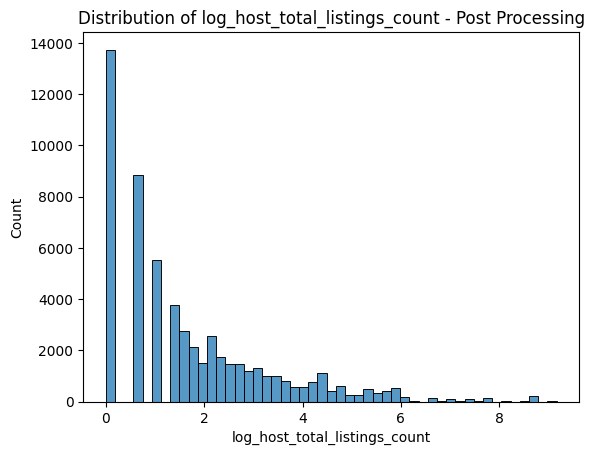

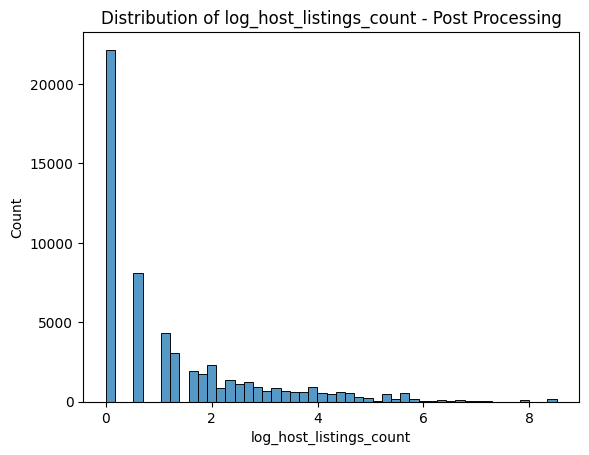

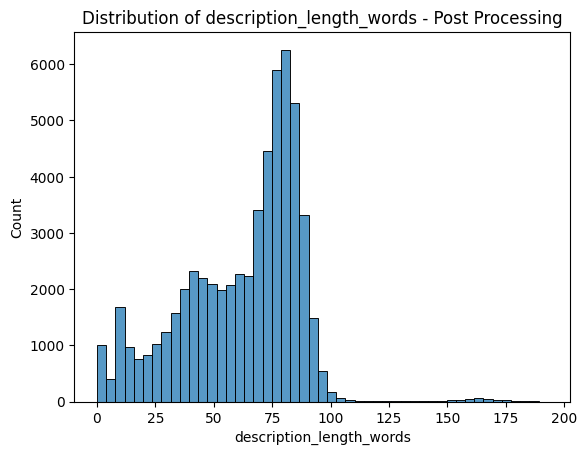

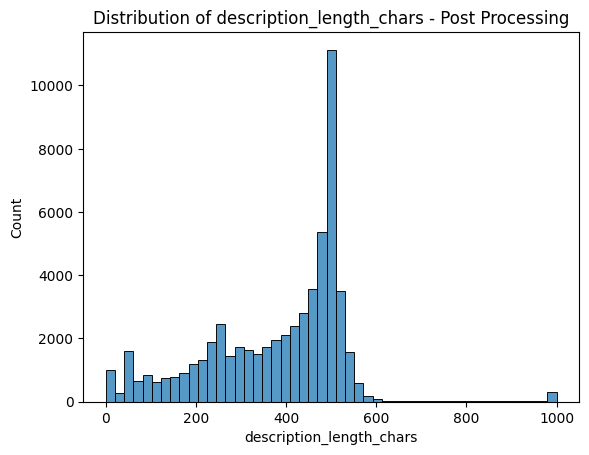

In [ ]:
numeric_columns = cleaned_df.columns[cleaned_df.dtypes.apply(lambda x: np.issubdtype(x, np.number))]
for col in numeric_columns:
    plt.figure()
    data = cleaned_df[col].dropna()
    bins = np.linspace(data.min(), data.max(), 50)
    sns.histplot(data, bins=bins)
    plt.title(f'Distribution of {col} - Post Processing')
    plt.xlabel(col)
    plt.show()


# Data Quality, Preliminaries & Target Variable

**Descriptive statistics**

In [ ]:
(
    cleaned_df
    .describe()
    .drop(columns=['last_scraped', 'host_since', 'first_review', 'last_review'])
    .T
    .round(2)
)


,count,mean,min,25%,50%,75%,max,std
host_response_rate,58044.0,95.68,0.00,100.00,100.00,100.00,1.000000e+02,15.90
host_acceptance_rate,58044.0,87.56,0.00,88.00,96.00,99.00,1.000000e+02,21.43
host_listings_count,58044.0,38.79,1.00,1.00,2.00,8.00,4.988000e+03,303.92
host_total_listings_count,58044.0,63.81,1.00,2.00,4.00,13.00,9.551000e+03,438.00
latitude,58044.0,36.89,33.34,34.05,34.16,40.71,4.091000e+01,3.30
longitude,58044.0,-99.42,-118.92,-118.35,-118.11,-73.96,-7.371000e+01,21.93
accommodates,58044.0,3.51,1.00,2.00,2.00,4.00,1.600000e+01,2.51
bathrooms,58044.0,1.38,0.00,1.00,1.00,1.50,1.600000e+01,0.85
bedrooms,58044.0,1.53,0.00,1.00,1.00,2.00,2.300000e+01,1.09
beds,58044.0,1.94,0.00,1.00,1.00,2.00,5.000000e+01,1.46


We added the column 'time_as_host' to translate the date the AirBnb host joined airbnb into ('host_since') into a integer format (days).

In [ ]:
from datetime import datetime
cleaned_df['host_since'] = pd.to_datetime(cleaned_df['host_since'], errors='coerce')
today = datetime.now()
cleaned_df['time_as_host'] = (today - cleaned_df['host_since']).dt.days
print(cleaned_df['time_as_host'])

1        4312
3        4232
4        5202
5        5301
6         638
         ... 
81992    3506
81993    3991
81994    2635
81995    4830
81996    2256
Name: time_as_host, Length: 58044, dtype: int64


**Correlation Analysis**

In [ ]:
global_corr = cleaned_df.corr(numeric_only=True)['review_scores_rating']

la_corr = cleaned_df[cleaned_df['city'] == 'LA'].corr(numeric_only=True)['review_scores_rating']
ny_corr = cleaned_df[cleaned_df['city'] == 'NY'].corr(numeric_only=True)['review_scores_rating']

correlation_comparison = pd.DataFrame({
    'Global_Correlation': global_corr,
    'LA_Correlation': la_corr,
    'NY_Correlation': ny_corr})

correlation_comparison = correlation_comparison.sort_values(by='Global_Correlation', ascending=False)


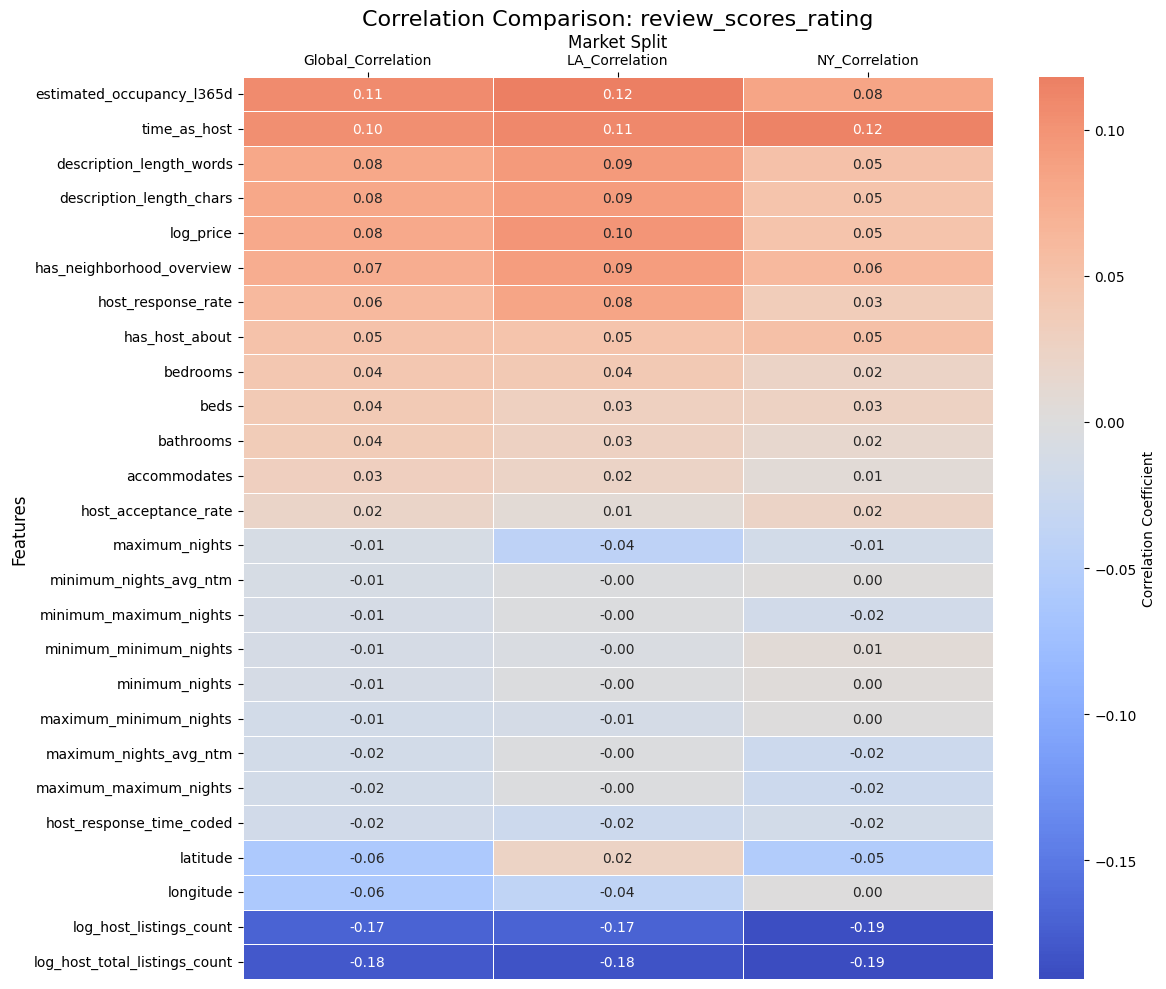

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

viz_data = correlation_comparison.drop(index=['review_scores_rating', 'host_listings_count', 'host_total_listings_count', 'price', 'host_acceptance_rate_imputed', 'host_is_superhost_imputed', 'log_price_imputed', 'host_response_rate_imputed'], errors='ignore')

plt.figure(figsize=(12, 10))
ax =sns.heatmap(viz_data,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title('Correlation Comparison: review_scores_rating', fontsize=16)
plt.ylabel('Features', fontsize=12)
plt.xlabel('Market Split', fontsize=12)
plt.tight_layout()

plt.savefig('correlation_heatmap.png')

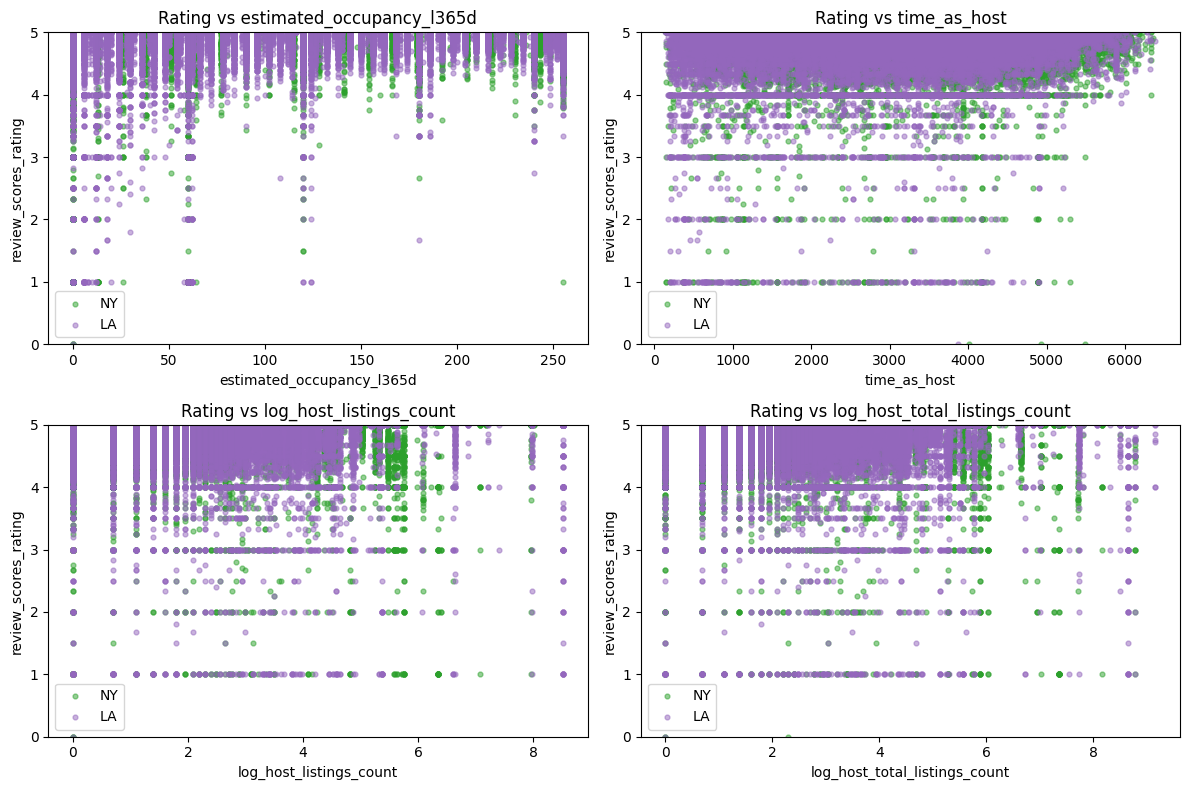

In [ ]:
features = [
    "estimated_occupancy_l365d",
    "time_as_host",
    "log_host_listings_count",
    "log_host_total_listings_count"
]

plt.figure(figsize=(12, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)

    for city, color in zip(["NY", "LA"], ["tab:green", "tab:purple"]):
        subset = cleaned_df[cleaned_df["city"] == city]
        plt.scatter(
            subset[col],
            subset["review_scores_rating"],
            alpha=0.5,
            s=12,
            label=city,
            color=color
        )

    plt.title(f"Rating vs {col}")
    plt.xlabel(col)
    plt.ylabel("review_scores_rating")
    plt.ylim(0, 5)
    plt.legend()

plt.tight_layout()
plt.show()



**Assessing host attributes**
Some are above in the correlations chart

In [ ]:
host_dtypes = cleaned_df.filter(like='host').dtypes

host_dtypes_df = host_dtypes.to_frame(name='Data Type')

print(host_dtypes_df)

                                    Data Type
host_name                              object
host_since                     datetime64[ns]
host_about                             object
host_response_time                     object
host_response_rate                    float64
host_acceptance_rate                  float64
host_is_superhost                      object
host_listings_count                   float64
host_total_listings_count             float64
host_verifications                     object
host_has_profile_pic                   object
host_is_superhost_imputed                bool
host_response_time_coded              float64
host_response_rate_imputed               bool
host_acceptance_rate_imputed             bool
has_host_about                           bool
log_host_total_listings_count         float64
log_host_listings_count               float64
time_as_host                            int64


Binary host attributes: Has profile pic, is superhost, has host about

--- Analysis for: host_has_profile_pic ---
Mean Rating (True):  4.7575 (n=57129)
Mean Rating (False): 4.6854 (n=915)
T-statistic:         3.5128
P-value:             0.0005
Conclusion: Statistically Significant difference.


--- Analysis for: host_is_superhost ---
Mean Rating (True):  4.8668 (n=22120)
Mean Rating (False): 4.6884 (n=35924)
T-statistic:         57.0701
P-value:             0.0000
Conclusion: Statistically Significant difference.


--- Analysis for: has_host_about ---
Mean Rating (True):  4.7749 (n=33773)
Mean Rating (False): 4.7306 (n=24271)
T-statistic:         11.7043
P-value:             0.0000
Conclusion: Statistically Significant difference.




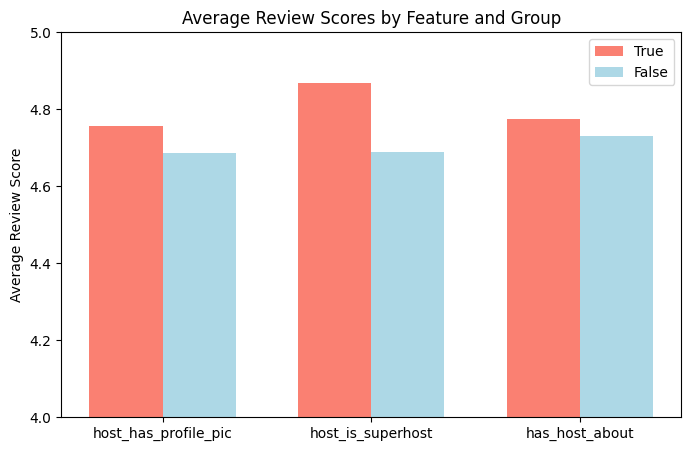

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

features_to_test = ['host_has_profile_pic', 'host_is_superhost', 'has_host_about']

labels = []
means_true = []
means_false = []

for feature in features_to_test:
    temp_df = cleaned_df[['review_scores_rating', feature]].dropna()

    group_true = temp_df[temp_df[feature].isin([True, 't', 1])]['review_scores_rating']
    group_false = temp_df[temp_df[feature].isin([False, 'f', 0])]['review_scores_rating']

    if len(group_true) > 1 and len(group_false) > 1:
        t_stat, p_val = stats.ttest_ind(group_true, group_false, equal_var=False)

        mean_true = group_true.mean()
        mean_false = group_false.mean()

        print(f"--- Analysis for: {feature} ---")
        print(f"Mean Rating (True):  {mean_true:.4f} (n={len(group_true)})")
        print(f"Mean Rating (False): {mean_false:.4f} (n={len(group_false)})")
        print(f"T-statistic:         {t_stat:.4f}")
        print(f"P-value:             {p_val:.4f}")

        if p_val < 0.05:
            print("Conclusion: Statistically Significant difference.")
        else:
            print("Conclusion: No statistically significant difference.")
        print("\n")


        labels.append(feature)
        means_true.append(mean_true)
        means_false.append(mean_false)

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, means_true, width, label='True', color='salmon')
plt.bar(x + width/2, means_false, width, label='False', color='lightblue')

plt.ylabel('Average Review Score')
plt.title('Average Review Scores by Feature and Group')
plt.xticks(x, labels)
plt.ylim(4, 5)
plt.legend()
plt.show()


**Property Attributes**

Created new column to group property types (group_property_type), added 'Unique stay' category to encompass non-traditional stays e.g. 'tower'

In [ ]:
# Created new column to group property types (group_property_type)
cleaned_df['property_type'].unique()

def group_property_type(x):
    x_str = str(x).lower()
    if "private" in x_str or "hotel" in x_str:
        return "Private room"
    elif "shared" in x_str:
        return "Shared room"
    elif "entire" in x_str or "studio" in x_str:
        return "Entire home/apt"
    else:
        return "Unique stay"

cleaned_df["property_type_grouped"] = cleaned_df["property_type"].apply(group_property_type)

print(cleaned_df["property_type_grouped"].value_counts())

property_type_grouped
Entire home/apt    38158
Private room       19193
Unique stay          409
Shared room          284
Name: count, dtype: int64


In [ ]:
mean_ratings = cleaned_df.groupby("property_type_grouped")["review_scores_rating"].mean()
print("Mean review_scores_rating by property_type_grouped:\n")
print(mean_ratings)
print('===================================================================')
import matplotlib.pyplot as plt

from scipy.stats import f_oneway

# Split ratings into groups
groups = [group["review_scores_rating"].dropna()
          for name, group in cleaned_df.groupby("property_type_grouped")]

# One-way ANOVA
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA result: F = {f_stat:.3f}, p = {p_value:.3f}")

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=cleaned_df["review_scores_rating"],
    groups=cleaned_df["property_type_grouped"],
    alpha=0.05
)
print(tukey)

Mean review_scores_rating by property_type_grouped:

property_type_grouped
Entire home/apt    4.784151
Private room       4.702275
Shared room        4.650035
Unique stay        4.775648
Name: review_scores_rating, dtype: float64
ANOVA result: F = 156.215, p = 0.000
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1        group2    meandiff p-adj   lower   upper  reject
-------------------------------------------------------------------
Entire home/apt Private room  -0.0819    0.0 -0.0918  -0.072   True
Entire home/apt  Shared room  -0.1341    0.0 -0.2008 -0.0674   True
Entire home/apt  Unique stay  -0.0085 0.9795 -0.0642  0.0471  False
   Private room  Shared room  -0.0522 0.1858 -0.1192  0.0147  False
   Private room  Unique stay   0.0734 0.0042  0.0174  0.1293   True
    Shared room  Unique stay   0.1256 0.0011  0.0391  0.2121   True
-------------------------------------------------------------------


*   Entire homes generally get higher ratings than private rooms, and than shared rooms (p < 0.001)
*   Unique stays generally rate higher than shared homes or private rooms (p < 0.001)
*   The difference between ratings of entire homes and unique stays, and of private rooms and shared rooms are not statistically significant.




In [ ]:
mean_ratings_room = cleaned_df.groupby("room_type")["review_scores_rating"].mean()
print("Mean review_scores_rating by room_type:\n")
print(mean_ratings_room)

import matplotlib.pyplot as plt

from scipy.stats import f_oneway

groups_room = [group["review_scores_rating"].dropna()
               for name, group in cleaned_df.groupby("room_type")]

f_stat, p_value = f_oneway(*groups_room)
print(f"ANOVA result: F = {f_stat:.3f}, p = {p_value:.3f}")

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_room = pairwise_tukeyhsd(
    endog=cleaned_df["review_scores_rating"],
    groups=cleaned_df["room_type"],
    alpha=0.05
)
print(tukey_room)

Mean review_scores_rating by room_type:

room_type
Entire home/apt    4.783443
Hotel room         4.483434
Private room       4.705426
Shared room        4.656835
Name: review_scores_rating, dtype: float64
ANOVA result: F = 167.024, p = 0.000
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1        group2    meandiff p-adj   lower   upper  reject
-------------------------------------------------------------------
Entire home/apt   Hotel room     -0.3    0.0 -0.3797 -0.2203   True
Entire home/apt Private room   -0.078    0.0 -0.0879 -0.0681   True
Entire home/apt  Shared room  -0.1266    0.0 -0.1918 -0.0614   True
     Hotel room Private room    0.222    0.0   0.142  0.3019   True
     Hotel room  Shared room   0.1734 0.0001  0.0707  0.2761   True
   Private room  Shared room  -0.0486 0.2248  -0.114  0.0169  False
-------------------------------------------------------------------


*   Entire homes generally get higher ratings than private rooms, and than shared rooms (p < 0.001)
*   Unique stays generally rate higher than shared homes or private rooms (p < 0.001)
*   The difference between ratings of entire homes and unique stays, and of private rooms and shared rooms are not statistically significant.
*   When analyzing the same data using the same data using the room_type categories, we found that entire homes generally performed better than any other room category, and hotel rooms performed better than other private or shared rooms.

In [ ]:
cleaned_df.loc[cleaned_df['bathrooms']==0, ['bathrooms', 'bathrooms_text']]

,bathrooms,bathrooms_text
8,0.0,0 baths
299,0.0,0 baths
530,0.0,0 baths
626,0.0,0 shared baths
1958,0.0,0 baths
...,...,...
81253,0.0,0 baths
81479,0.0,0 shared baths
81568,0.0,0 baths
81577,0.0,0 shared baths


In [ ]:
for col in ["bathrooms", "bedrooms", "beds"]:
    print(f"\n--- Tukey HSD for {col} (significant comparisons only) ---")

    tukey = pairwise_tukeyhsd(
        endog=cleaned_df["review_scores_rating"],
        groups=cleaned_df[col],
        alpha=0.05
    )
    tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                            columns=tukey._results_table.data[0])

    sig_results = tukey_df[tukey_df['reject'] == True]

    if not sig_results.empty:
        print(sig_results)
    else:
        print("No significant differences")




--- Tukey HSD for bathrooms (significant comparisons only) ---
     group1  group2  meandiff   p-adj   lower   upper  reject
1       0.0     1.0    0.1966  0.0000  0.0963  0.2969    True
2       0.0     1.5    0.2305  0.0000  0.1256  0.3355    True
3       0.0     2.0    0.2067  0.0000  0.1052  0.3082    True
4       0.0     2.5    0.2680  0.0000  0.1601  0.3759    True
5       0.0     3.0    0.2360  0.0000  0.1284  0.3436    True
6       0.0     3.5    0.2784  0.0000  0.1592  0.3975    True
7       0.0     4.0    0.2297  0.0000  0.1068  0.3526    True
8       0.0     4.5    0.2878  0.0000  0.1514  0.4242    True
9       0.0     5.0    0.2358  0.0000  0.0713  0.4002    True
10      0.0     5.5    0.3034  0.0000  0.1287  0.4781    True
11      0.0     6.0    0.2710  0.0006  0.0615  0.4804    True
12      0.0     6.5    0.3222  0.0480  0.0011  0.6434    True
13      0.0     7.0    0.3443  0.0011  0.0701  0.6186    True
51      1.0     1.5    0.0339  0.0345  0.0010  0.0669    True
53    

Improve summary: Having a bathroom basically always statistically improves ratings compared to no bathroom, but after that comparing houses with multiple bathrooms does not change rating

4. Listing attributes
minimum_nights, maximum_nights
instant_bookable
availability_365

In [ ]:
temp_df = cleaned_df[['review_scores_rating', 'instant_bookable']].dropna()

group_instant = temp_df[temp_df['instant_bookable'].isin([True, 't', 1])]['review_scores_rating']
group_not_instant = temp_df[temp_df['instant_bookable'].isin([False, 'f', 0])]['review_scores_rating']

t_stat, p_val = stats.ttest_ind(
    group_instant,
    group_not_instant,
    equal_var=False
)


print("--- Instant Bookability vs Review Scores ---")
print(f"Mean Rating (Instant bookable):     {group_instant.mean():.4f} (n={len(group_instant)})")
print(f"Mean Rating (Not instant bookable): {group_not_instant.mean():.4f} (n={len(group_not_instant)})")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: Properties with instant bookability have significantly different review scores.")
else:
    print("Conclusion: No statistically significant difference in review scores.")

--- Instant Bookability vs Review Scores ---
Mean Rating (Instant bookable):     4.6855 (n=12813)
Mean Rating (Not instant bookable): 4.7764 (n=45231)
T-statistic: -17.9742
P-value:     0.0000
Conclusion: Properties with instant bookability have significantly different review scores.


In [ ]:
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

d = cleaned_df[["review_scores_rating","city","host_is_superhost"]].dropna().copy()

# 1) Superhost vs non-Superhost
a = d[d["host_is_superhost"]==False]["review_scores_rating"]
b = d[d["host_is_superhost"]==True]["review_scores_rating"]
print("Superhost vs Non (p):", mannwhitneyu(a, b, alternative="two-sided").pvalue)
print("Δmean:", b.mean()-a.mean(), "Δmedian:", b.median()-a.median())

# 2) LA vs NY
la = d[d["city"]=="LA"]["review_scores_rating"]
ny = d[d["city"].isin(["NY","NYC"])]["review_scores_rating"]
print("LA vs NY (p):", mannwhitneyu(la, ny, alternative="two-sided").pvalue)
print("Δmean:", la.mean()-ny.mean(), "Δmedian:", la.median()-ny.median())

# 3) Interaction: city × superhost
m = smf.ols("review_scores_rating ~ C(city) * C(host_is_superhost)", data=d).fit(cov_type="HC3")
print(m.params)
print(m.pvalues)   # look for the interaction term


Superhost vs Non (p): 0.0
Δmean: 0.17836288282294976 Δmedian: 0.08999999999999986
LA vs NY (p): 4.8944825712930645e-93
Δmean: 0.05286729809179036 Δmedian: 0.04999999999999982
Intercept                                     4.694696
C(city)[T.NY]                                -0.012306
C(host_is_superhost)[T.True]                  0.177389
C(city)[T.NY]:C(host_is_superhost)[T.True]   -0.006405
dtype: float64
Intercept                                     0.000000
C(city)[T.NY]                                 0.023580
C(host_is_superhost)[T.True]                  0.000000
C(city)[T.NY]:C(host_is_superhost)[T.True]    0.317095
dtype: float64


#NYC vs LA

In [ ]:
summary = (
    cleaned_df.groupby("city")
      .agg(
          n_listings=("city", "size"),
          median_price=("price", "median"),
          median_log_price=("log_price", "median"),
          mean_occupancy_l365d=("estimated_occupancy_l365d", "mean"),
          median_occupancy_l365d=("estimated_occupancy_l365d", "median"),
          mean_review_rating=("review_scores_rating", "mean"),
          pct_instant_bookable=("instant_bookable", lambda s: 100 * s.mean()),
          pct_superhost=("host_is_superhost", lambda s: 100 * s.mean()),
          median_min_nights_avg_ntm=("minimum_nights_avg_ntm", "median"),
      )
      .reset_index()
)

summary

,city,n_listings,median_price,median_log_price,mean_occupancy_l365d,median_occupancy_l365d,mean_review_rating,pct_instant_bookable,pct_superhost,median_min_nights_avg_ntm
0,LA,33330,150.0,4.969813,85.598590,60.0,4.778872,24.905491,47.452745,4.0
1,NY,24714,149.0,5.010635,68.443514,0.0,4.726004,18.256858,25.507809,30.0


In [ ]:
room_stats = (
    cleaned_df.groupby(["city","property_type_grouped"])
      .agg(
          n=("city","size"),
          med_price=("price","median"),
          med_occ=("estimated_occupancy_l365d","median"),
          mean_occ=("estimated_occupancy_l365d","mean"),
          med_min_nights=("minimum_nights_avg_ntm","median")
      )
      .reset_index()
      .sort_values(["property_type_grouped","city"])
)
room_stats["pct_in_city"] = room_stats["n"] / room_stats.groupby("city")["n"].transform("sum") * 100
room_stats = room_stats.sort_values(["city","pct_in_city"], ascending=[True, False])


room_stats


,city,property_type_grouped,n,med_price,med_occ,mean_occ,med_min_nights,pct_in_city
0,LA,Entire home/apt,24815,180.0,60.0,92.947129,4.6,74.452445
1,LA,Private room,7991,69.0,24.0,63.214616,3.0,23.975398
3,LA,Unique stay,370,115.0,54.0,88.854054,2.0,1.110111
2,LA,Shared room,154,32.0,45.0,55.155844,30.0,0.462046
4,NY,Entire home/apt,13343,185.0,0.0,66.383122,30.0,53.989641
5,NY,Private room,11202,95.0,0.0,70.709159,30.0,45.326536
6,NY,Shared room,130,106.0,60.0,98.815385,30.0,0.526018
7,NY,Unique stay,39,175.0,0.0,21.358974,30.0,0.157805


Divide minimum nights avg into bins

In [ ]:
bins = [-1, 6, 29, 89, 3650]
labels = ["1-6", "7-29", "30-89", "90+"]

cleaned_df["min_nights_bin"] = pd.cut(df["minimum_nights_avg_ntm"], bins=bins, labels=labels)

stay_mix = (
    cleaned_df.groupby(["city","min_nights_bin"])
      .size()
      .reset_index(name="n")
)

stay_mix["pct_in_city"] = stay_mix["n"] / stay_mix.groupby("city")["n"].transform("sum") * 100
stay_mix = stay_mix.sort_values(["city","min_nights_bin"])

stay_mix

/tmp/ipython-input-2783898631.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cleaned_df.groupby(["city","min_nights_bin"])


,city,min_nights_bin,n,pct_in_city
0,LA,1-6,17774,53.327333
1,LA,7-29,1698,5.094509
2,LA,30-89,13581,40.747075
3,LA,90+,277,0.831083
4,NY,1-6,4324,17.496156
5,NY,7-29,196,0.793073
6,NY,30-89,19891,80.484745
7,NY,90+,303,1.226026


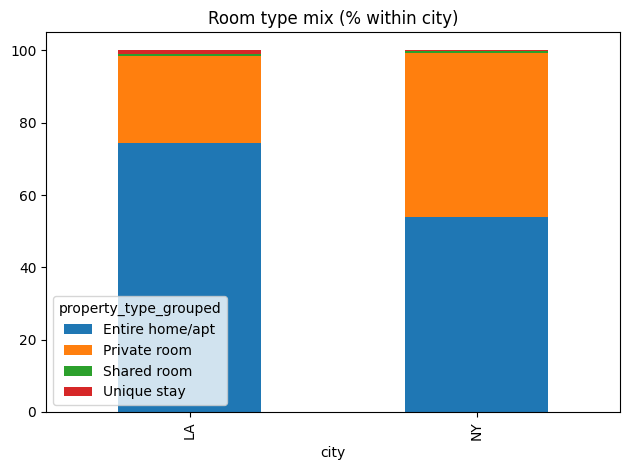

In [ ]:
pd.crosstab(cleaned_df["city"], cleaned_df["property_type_grouped"], normalize="index").mul(100).plot(kind="bar", stacked=True)
plt.title("Room type mix (% within city)")
plt.tight_layout()

plt.show()


In [ ]:
cleaned_df.groupby("city")["accommodates"].agg(["count","median","mean"]).round(2)


,count,median,mean
city,,,
LA,33330,3.0,4.05
NY,24714,2.0,2.77


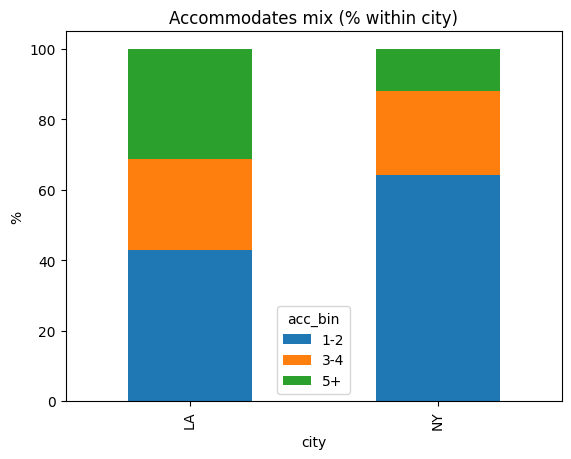

In [ ]:
bins = [0, 2, 4, 99]
labels = ["1-2", "3-4", "5+"]

cleaned_df["acc_bin"] = pd.cut(cleaned_df["accommodates"], bins=bins, labels=labels)

acc_mix = pd.crosstab(cleaned_df["city"], cleaned_df["acc_bin"], normalize="index") * 100
acc_mix = acc_mix.round(2)
acc_mix

acc_mix.plot(kind="bar", stacked=True)
plt.title("Accommodates mix (% within city)")
plt.ylabel("%")
plt.show()


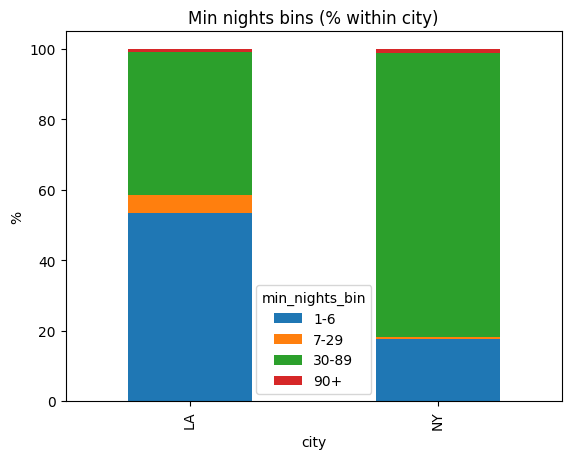

In [ ]:
pd.crosstab(cleaned_df["city"], cleaned_df["min_nights_bin"], normalize="index").mul(100).plot(kind="bar", stacked=True)
plt.title("Min nights bins (% within city)")
plt.ylabel("%")
plt.show()


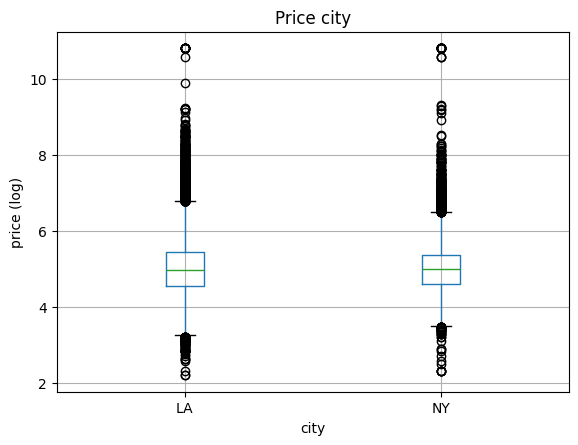

In [ ]:
cleaned_df.boxplot(column="log_price", by="city")
plt.title("Price city")
plt.suptitle("")
plt.ylabel("price (log)")
plt.show()


<Figure size 1200x500 with 0 Axes>

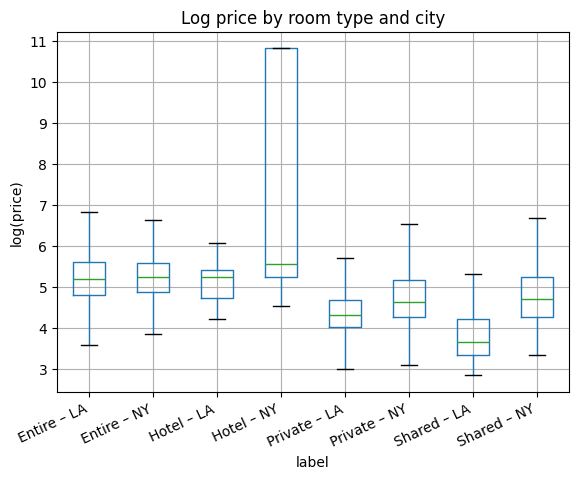

In [ ]:
d = cleaned_df[cleaned_df["room_type"].isin([
    "Entire home/apt",
    "Hotel room",
    "Private room",
    "Shared room"
])].copy()

d["label"] = (
    d["room_type"]
      .replace({
          "Entire home/apt": "Entire",
          "Hotel room": "Hotel",
          "Private room": "Private",
          "Shared room": "Shared"
      })
    + " – " + d["city"]
)

plt.figure(figsize=(12,5))
d.boxplot(column="log_price", by="label", showfliers=False)
plt.title("Log price by room type and city")
plt.suptitle("")
plt.ylabel("log(price)")
plt.xticks(rotation=25, ha="right")
plt.show()

In [ ]:
cleaned_df.groupby(["room_type","city"]).size().unstack(fill_value=0)


city,LA,NY
room_type,,
Entire home/apt,25217,13427
Hotel room,105,93
Private room,7841,11064
Shared room,167,130


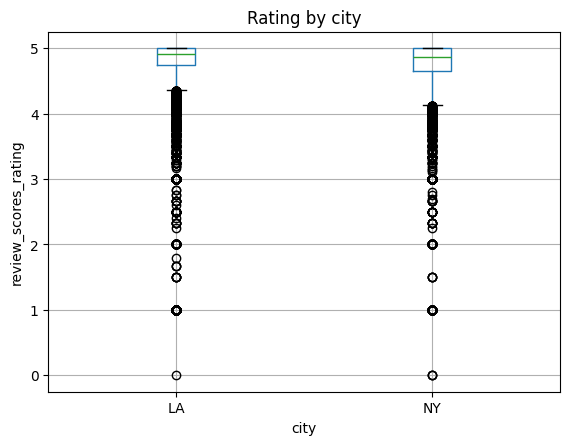

In [ ]:
cleaned_df.boxplot(column="review_scores_rating", by="city")
plt.title("Rating by city")
plt.suptitle("")
plt.ylabel("review_scores_rating")
plt.show()


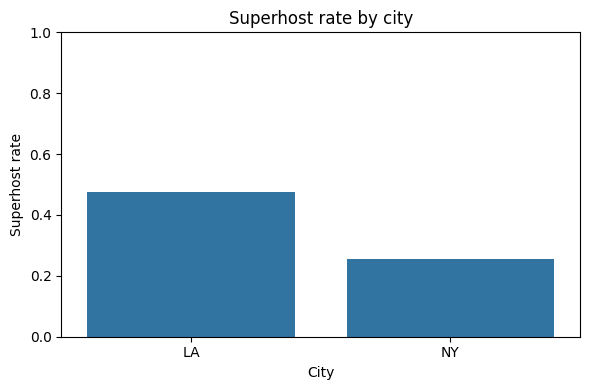

In [ ]:
superhost = (
    cleaned_df.groupby("city")["host_is_superhost"]
              .value_counts(normalize=True)
              .rename("share")
              .reset_index()
)

superhost_true = superhost[superhost["host_is_superhost"].astype(str).str.lower().isin(["t","true"])]

plt.figure(figsize=(6,4))
sns.barplot(data=superhost_true, x="city", y="share")
plt.title("Superhost rate by city")
plt.xlabel("City")
plt.ylabel("Superhost rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
g = (cleaned_df.groupby(["city","host_is_superhost"])["review_scores_rating"]
       .mean()
       .unstack())

print(g)

uplift_LA = g.loc["LA", True] - g.loc["LA", False]
uplift_NY = g.loc["NY", True] - g.loc["NY", False]
interaction = uplift_NY - uplift_LA

print("uplift_LA:", uplift_LA)
print("uplift_NY:", uplift_NY)
print("interaction (NY-LA):", interaction)


host_is_superhost     False     True 
city                                 
LA                 4.694696  4.872085
NY                 4.682390  4.853374
uplift_LA: 0.17738892584176735
uplift_NY: 0.17098404279151946
interaction (NY-LA): -0.006404883050247889


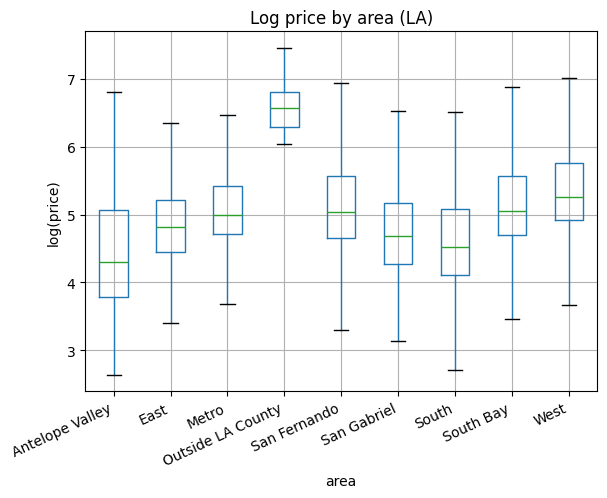

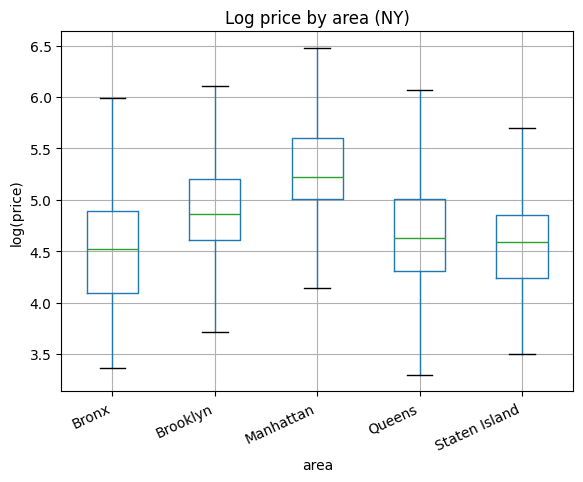

In [ ]:
for c in ["LA","NY"]:
    sub = cleaned_df[cleaned_df["city"]==c]
    sub.boxplot(column="log_price", by="area", showfliers=False)
    plt.title(f"Log price by area ({c})")
    plt.suptitle("")
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("log(price)")
    plt.show()

LA and NY appear to serve different guest segments. In NY, the supply is dominated by city apartments (entire units) with a relatively large share of private rooms, and many listings are configured for long minimum stays (30+ days).

This pattern is consistent with smaller parties (singles/couples) and longer-term urban stays (e.g., work, study, temporary relocation).

In LA, listings tend to accommodate more guests (median accommodates ≈ 3 vs ≈ 2 in NY) and short stays (1-6 days) are more common, which aligns with leisure travel and small groups/families.

Within each city, prices vary substantially by area, confirming that location is a major driver of price. In NYC, Manhattan has the highest median log price, followed by Brooklyn and Queens, with Bronx and Staten Island lower. In LA, price differences across areas are also pronounced; however, the “Outside LA County” category shows unusually high prices and should be interpreted cautiously due to very small sample size and potential outliers.

LA has a substantially higher Superhost share than NY (47% vs 26%). Despite this difference in prevalence, the Superhost rating uplift is nearly identical across cities (+0.19 points; interaction ≈ 0.006), suggesting Superhost status is associated with higher ratings similarly in both LA and NY, but is more common in LA.
